In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
import pandas as pd
import re
from itertools import combinations
from itertools import combinations
from scipy.stats import spearmanr
from pathlib import Path

In [33]:
# import GC-MS data
daucus_carota = pd.read_csv('Volatile_data_GENESISS/Daucus_carota_compound_summary_mod.csv', engine='python')
lactuca_serriola = pd.read_csv('Volatile_data_GENESISS/Lactuca_serriola_compound_summary_mod.csv', engine='python')
papaver_rhoeas = pd.read_csv('Volatile_data_GENESISS/Papaver_rhoeas_compound_summary_mod.csv', engine='python')
vaccinium_oxycoccus = pd.read_csv('Volatile_data_GENESISS/Vaccinium_oxycoccus_compound_summary_mod.csv', engine='python')
ficus_sycomorus = pd.read_csv('Volatile_data_GENESISS/Ficus_sycomorus_compound_summary_mod.csv', engine='python')
mesembryanthemum_crystallinum = pd.read_csv('Volatile_data_GENESISS/Mesembryanthemum_crystallinum_compound_summary_mod.csv', engine='python')
trifolium_pratense = pd.read_csv('Volatile_data_GENESISS/Trifolium_pratense_compound_summary_mod.csv', engine='python')
empty_vial = pd.read_csv('Volatile_data_GENESISS/empty_vial_data.csv', engine='python')

# import metadata
metadata = pd.read_csv('Volatile_data_GENESISS/GC-MS_metadata.csv', engine='python')
metadata.drop(columns=['Unnamed: 7', 'Unnamed: 8', 'container mass_mg:', '209.537'])

,sample_name,species,treatment,replicate,sample_mass_mg,seed_mass_mg,n_seeds
0,231006_SPME_703840_Daucus carota,Daucus carota,vacuum_whole,1,20.7,0.8513,24.0
1,231215_SPME_703840_Daucus carota_2,Daucus carota,vacuum_whole,2,20.4,0.8513,24.0
2,240215_SPME_703840_Daucus carota_3,Daucus carota,vacuum_whole,3,20.5,0.8513,24.0
3,240510_703840_Daucus carota_cut seed_1,Daucus carota,vacuum_cut,1,20.8,0.8513,24.0
4,240704_703840_Daucus carota_cut seeds_2,Daucus carota,vacuum_cut,2,20.3,0.8513,24.0
...,...,...,...,...,...,...,...
68,240627_49535_T pratense_cut seeds_2,Trifolium pratense,vacuum_cut,2,20.6,1.5393,13.0
69,250703_49535_Trifolium pratense_cut seeds_Rep3,Trifolium pratense,vacuum_cut,3,20.5,1.5393,13.0
70,251009_49535_R1_20_4MG_normal_atm,Trifolium pratense,normal_atm_whole,1,20.4,1.5393,13.0
71,251009_49535_R2_20_0MG_normal_atm,Trifolium pratense,normal_atm_whole,2,20.0,1.5393,13.0


In [3]:
# merge dataframes from each species into one
df = pd.concat([daucus_carota, lactuca_serriola, papaver_rhoeas, vaccinium_oxycoccus, ficus_sycomorus, mesembryanthemum_crystallinum, trifolium_pratense, empty_vial], ignore_index=True)

In [4]:
# remove unnecessary columns
KEEP_COLS = {
    "Name": "compound_name",
    "CAS": "CAS",
    "RT": "RT",
    "Start": "RT_start",
    "End": "RT_end",
    "Area": "area",
    "Sample Name": "sample_name",
    "Score (Lib)": "library_score",
    "Mass (DB)": "mass_db",
}

df = df[list(KEEP_COLS)].rename(columns=KEEP_COLS)
df = df.drop_duplicates(subset=[
    "sample_name","RT","RT_start","RT_end","area","compound_name"
])

In [ ]:
# merge with metadata
df = df.merge(
    metadata,
    on="sample_name",
    how="left",
    validate="many_to_one"
)

In [6]:
# get normalised areas
df["area/sample_mass"] = df["area"] / df["sample_mass_mg"]
df["area/n_seeds"] = df["area"] / df["n_seeds"]
df["RT"] = pd.to_numeric(df["RT"], errors="coerce")
df["area"] = pd.to_numeric(df["area"], errors="coerce")
df.head()

,compound_name,CAS,RT,RT_start,RT_end,area,sample_name,library_score,mass_db,species,...,replicate,sample_mass_mg,seed_mass_mg,n_seeds,Unnamed: 7,Unnamed: 8,container mass_mg:,209.537,area/sample_mass,area/n_seeds
0,NaN,NaN,2.365,2.338,2.502,16681904,231006_SPME_703840_Daucus carota,NaN,NaN,Daucus carota,...,1,20.7,0.8513,24.0,NaN,NaN,NaN,NaN,805889.082126,695079.333333
1,Oxygen,7782-44-7,2.850,2.796,2.996,11584768,231006_SPME_703840_Daucus carota,92.11,31.990,Daucus carota,...,1,20.7,0.8513,24.0,NaN,NaN,NaN,NaN,559650.628019,482698.666667
2,NaN,NaN,3.334,3.281,3.427,365816,231006_SPME_703840_Daucus carota,NaN,NaN,Daucus carota,...,1,20.7,0.8513,24.0,NaN,NaN,NaN,NaN,17672.270531,15242.333333
3,NaN,NaN,3.450,3.427,3.488,100204,231006_SPME_703840_Daucus carota,NaN,NaN,Daucus carota,...,1,20.7,0.8513,24.0,NaN,NaN,NaN,NaN,4840.772947,4175.166667
4,Acetone,67-64-1,3.534,3.488,3.665,1045012,231006_SPME_703840_Daucus carota,97.10,58.042,Daucus carota,...,1,20.7,0.8513,24.0,NaN,NaN,NaN,NaN,50483.671498,43542.166667


In [ ]:
# filter out empty vial samples
df_empty = df[df['species']=='Empty']

In [ ]:
# create global ID map for compounds
BAD = {"", "nan", "none", "unknown", "unidentified"}
def norm_compound(x):
    s = "" if x is None else str(x)
    s = s.strip().lower()
    s = s.replace("–", "-").replace("−", "-")
    s = re.sub(r"\s+", " ", s)
    return s

def build_global_id_map(df, compound_col="compound_name"):
    comp_norm = df[compound_col].map(norm_compound)
    comp_norm = comp_norm[~comp_norm.isin(BAD)]
    uniq = sorted(comp_norm.dropna().unique().tolist())
    return {name: i + 1 for i, name in enumerate(uniq)}

# include all compounds, so IDs are consistent across filtered and unfiltered data
GLOBAL_ID_MAP = build_global_id_map(df, compound_col="compound_name")
ID_TO_COMPOUND = {v: k for k, v in GLOBAL_ID_MAP.items()}

key = (pd.Series(GLOBAL_ID_MAP, name="id")
         .reset_index()
         .rename(columns={"index": "compound_name"})
         .sort_values("id"))
print(key.to_string(index=False))

                                                                                                                                 compound_name  id
                                                                                                                                  (+)-4-carene   1
                                                                                                            (+)-cis-verbenol, trimethylacetate   2
                                                                                                                      (-)-isoaromadendrene-(v)   3
                                                                                                                               (-)-spathulenol   4
                                                                                                             (1-methylpenta-1,3-dienyl)benzene   5
                                                                            (1s,2e,6e,10r)-3,7,11,11-tetramethylbicycl

In [ ]:
# add normalised compound names and IDs to dataframe
df["compound_norm"] = df["compound_name"].map(norm_compound)
df["compound_id"] = df["compound_norm"].map(GLOBAL_ID_MAP)
df["compound_id"] = df["compound_id"].astype("Int64")
df

,compound_name,CAS,RT,RT_start,RT_end,area,sample_name,library_score,mass_db,species,...,seed_mass_mg,n_seeds,Unnamed: 7,Unnamed: 8,container mass_mg:,209.537,area/sample_mass,area/n_seeds,compound_norm,compound_id
0,NaN,NaN,2.365,2.338,2.502,16681904,231006_SPME_703840_Daucus carota,NaN,NaN,Daucus carota,...,0.8513,24.0,NaN,NaN,NaN,NaN,805889.082126,695079.333333,nan,<NA>
1,Oxygen,7782-44-7,2.850,2.796,2.996,11584768,231006_SPME_703840_Daucus carota,92.11,31.990,Daucus carota,...,0.8513,24.0,NaN,NaN,NaN,NaN,559650.628019,482698.666667,oxygen,570
2,NaN,NaN,3.334,3.281,3.427,365816,231006_SPME_703840_Daucus carota,NaN,NaN,Daucus carota,...,0.8513,24.0,NaN,NaN,NaN,NaN,17672.270531,15242.333333,nan,<NA>
3,NaN,NaN,3.450,3.427,3.488,100204,231006_SPME_703840_Daucus carota,NaN,NaN,Daucus carota,...,0.8513,24.0,NaN,NaN,NaN,NaN,4840.772947,4175.166667,nan,<NA>
4,Acetone,67-64-1,3.534,3.488,3.665,1045012,231006_SPME_703840_Daucus carota,97.10,58.042,Daucus carota,...,0.8513,24.0,NaN,NaN,NaN,NaN,50483.671498,43542.166667,acetone,291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9416,NaN,NaN,27.663,27.617,27.725,403720,230921_SPME_blank,NaN,NaN,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,<NA>
9417,NaN,NaN,27.763,27.725,27.802,291936,230921_SPME_blank,NaN,NaN,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,<NA>
9418,NaN,NaN,27.863,27.802,27.933,1356060,230921_SPME_blank,NaN,NaN,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,<NA>
9419,NaN,NaN,28.171,28.133,28.263,330602,230921_SPME_blank,NaN,NaN,Empty,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,<NA>


In [ ]:
# create lookup table for compound IDs and names
ID_TO_NAME = (
    df[["compound_id", "compound_name"]]
    .dropna(subset=["compound_id"])
    .drop_duplicates()
    .set_index("compound_id")["compound_name"]
    .to_dict()
)

compound_table = (
    pd.DataFrame(
        [(v, k) for k, v in GLOBAL_ID_MAP.items()],
        columns=["compound_id", "compound_name"]
    )
    .sort_values("compound_id")
)

#compound_table.to_csv("compound_id_lookup.csv", index=False)

In [11]:
# remove faulty replicates
# when it comes to creating a final filtered dataset, you should remove these faulty replicates before filtering by RT and compound ID
# when producing the chromatograms, to explore which replicates are faulty, you may wish to skip over running this cell

df = df[~(
    (df["species"] == "Papaver rhoeas") &
    (df["treatment"] == "vacuum_cut") &
    (df["replicate"].isin([1, 2, 3]))
)].copy()

df = df[~(
    (df["species"] == "Ficus sycomorus") &
    (df["treatment"].isin(["vacuum_whole", "vacuum_cut"])) &
    (df["replicate"] == 2)
)].copy()

df = df[~(
    (df["species"] == "Mesembryanthemum crystallinum") &
    (df["treatment"] == "vacuum_cut") &
    (df["replicate"] == 2)
)].copy()

df = df[~(
    (df["species"] == "Lactuca serriola") &
    (df["treatment"] == "vacuum_whole") &
    (df["replicate"] == 3)
)].copy()

df = df[~(
    (df["species"] == "Trifolium pratense") &
    (df["treatment"] == "vacuum_whole") &
    (df["replicate"] == 2)
)].copy()

In [ ]:
# remove seed peaks that match empty-vial peaks (same compound_id + within RT tolerance)
def remove_seed_peaks_matching_empty(
    df,
    rt_col="RT",
    compound_id_col="compound_id",
    treatment_col="treatment",
    species_col="species",
    rt_tol_seconds=10,
    rt_units="minutes",
    empty_species="Empty",
    empty_treatment_map=None,
    keep_empty_rows=True,
):
    """
    Remove seed peaks that match empty-vial peaks
    (same compound_id + within RT tolerance).

    - Only acts on rows with a non-null compound_id.
    - Unidentified peaks (compound_id is NA) are never removed.
    """

    rt_tol = rt_tol_seconds / 60.0 if rt_units == "minutes" else rt_tol_seconds
    d = df.copy()

    # Split seed and empty
    seed_df = d[d[species_col] != empty_species].copy()
    empty_df = d[d[species_col] == empty_species].copy()

    # Only identified (has ID) empties participate in matching
    empty_df = empty_df[empty_df[compound_id_col].notna()].copy()

    # Pre-sort empty by RT for efficient searching
    empty_df = empty_df.sort_values(rt_col)

    keep_mask = np.ones(len(seed_df), dtype=bool)

    # Determine corresponding empty treatment
    if empty_treatment_map is None:
        def map_empty(trt: str) -> str:
            return "vacuum_empty" if "vacuum" in str(trt).lower() else "normal_atm_empty"
    else:
        def map_empty(trt: str) -> str:
            return empty_treatment_map.get(trt, trt)

    # Loop per treatment (normal vs vacuum)
    for treatment in seed_df[treatment_col].dropna().unique():
        empty_treatment = map_empty(treatment)

        empty_sub = empty_df[empty_df[treatment_col] == empty_treatment]
        if empty_sub.empty:
            continue

        empty_rt = empty_sub[rt_col].to_numpy()
        # Use plain numpy array; IDs may be Int64 dtype, so coerce to float/object safe
        empty_ids = empty_sub[compound_id_col].to_numpy()

        seed_idx = seed_df[seed_df[treatment_col] == treatment].index

        for idx in seed_idx:
            row = seed_df.loc[idx]

            cid_seed = row.get(compound_id_col, np.nan)
            if pd.isna(cid_seed):
                continue  # never remove unidentified peaks

            rt_seed = row[rt_col]

            # Find empty peaks within RT tolerance
            lo = np.searchsorted(empty_rt, rt_seed - rt_tol, side="left")
            hi = np.searchsorted(empty_rt, rt_seed + rt_tol, side="right")
            if lo == hi:
                continue

            # Check compound ID match within the RT window
            if np.any(empty_ids[lo:hi] == cid_seed):
                keep_mask[seed_df.index.get_loc(idx)] = False

    filtered_seed = seed_df[keep_mask].copy()

    if keep_empty_rows:
        return pd.concat([filtered_seed, empty_df], ignore_index=True)
    return filtered_seed

df_filtered = remove_seed_peaks_matching_empty(df)

In [ ]:
# Filter out peaks that do not have replicate support (same compound ID + within RT tolerance in another replicate of the same species × treatment group).
def filter_peaks_by_replicate_support(
    df,
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    rt_col="RT",
    compound_col="compound_name",
    rt_tol_seconds=10,
    rt_units="minutes",
    norm_compound_fn=None,
    bad_compounds=None,
    require_n_other=1,
    require_same_compound=True,
    keep_single_replicate_groups=True
):
    """
    Filter peaks by replicate support.

    If require_same_compound=True:
        Keep peak only if another replicate has a peak
        within ±rt_tol_seconds AND with the same compound assignment.

    If require_same_compound=False:
        Only require RT proximity across replicates (ignore compound).

    require_n_other:
        Number of OTHER replicates required for support.
    """

    # ---- Convert tolerance ----
    if rt_units == "minutes":
        rt_tol = rt_tol_seconds / 60.0
    else:
        rt_tol = rt_tol_seconds

    if bad_compounds is None:
        bad_compounds = {"", "nan", "none", "unknown", "unidentified"}
    bad_norm = {str(x).strip().lower() for x in bad_compounds}

    keep = pd.Series(False, index=df.index)

    d = df.copy()

    # ---- Normalise compound names ----
    if norm_compound_fn is not None:
        d["_comp_norm"] = d[compound_col].map(norm_compound_fn)
    else:
        d["_comp_norm"] = d[compound_col].astype(str).str.strip()

    comp_norm = d["_comp_norm"].astype(str).str.strip().str.lower()
    is_identified = ~comp_norm.isin({str(x).lower() for x in bad_compounds})

    # ---- Group by species × treatment ----
    for (sp, trt), grp in d.groupby([species_col, treatment_col], sort=False):

        if grp[replicate_col].nunique() < 2:
            if keep_single_replicate_groups:
                keep.loc[grp.index] = True
            continue

        grp = grp.sort_values(rt_col)
        idx = grp.index.to_numpy()
        rts = grp[rt_col].to_numpy()
        reps = grp[replicate_col].to_numpy()
        comps = grp["_comp_norm"].to_numpy()

        for i in range(len(grp)):
            rt_i = rts[i]
            rep_i = reps[i]
            comp_i = comps[i]

            # Identify RT window
            lo = np.searchsorted(rts, rt_i - rt_tol, side="left")
            hi = np.searchsorted(rts, rt_i + rt_tol, side="right")

            # Exclude same replicate
            other_mask = reps[lo:hi] != rep_i

            if require_same_compound:
                # skip if this peak is unidentified
                if comp_i is None or str(comp_i).strip().lower() in bad_norm:
                    continue  # unidentified cannot satisfy strict criterion

                same_comp = comps[lo:hi] == comp_i
                supported = np.sum(other_mask & same_comp) >= require_n_other
            else:
                supported = np.sum(other_mask) >= require_n_other

            if supported:
                keep.loc[idx[i]] = True

    return df.loc[keep].copy()

df_filtered = filter_peaks_by_replicate_support(df_filtered, require_same_compound=True)

In [15]:
def plot_replicate_peaks(
    ax,
    dsr,
    rt_start_col="RT_start",
    rt_end_col="RT_end",
    rt_peak_col="RT",
    y_col="area/sample_mass",
    compound_col="compound_name",
    id_map=None,
    show_ids=True,
    max_labels=200,
    label_min_y=None,
    overlay_style=None,
):

    # Ensure axis scale/limits are set BEFORE using ymin as baseline
    ax.set_yscale("log")

    ymin = ax.get_ylim()[0]

    # Sort by height so big peaks draw last
    dsr = dsr.sort_values(y_col)

    labeled = 0

    # keep track of previous label positions to avoid overlap
    label_positions = []

    def place_label(ax, x, y, text, label_positions, min_dx=0.03, y_step=1.25):
        """
        Place a label above a peak, nudging it upward if it would overlap
        with an existing label at similar RT.
        """
        y_text = y * 1.15  # initial offset above peak

        for (x_prev, y_prev) in label_positions:
            if abs(x - x_prev) < min_dx:
                y_text = max(y_text, y_prev * y_step)

        ax.annotate(
            text,
            xy=(x, y),
            xytext=(x, y_text),
            textcoords="data",
            ha="center",
            va="bottom",
            fontsize=8,
            color="0.1",
            zorder=50,
            clip_on=False,
            arrowprops=dict(arrowstyle="-", lw=0.4, color="0.4"),
        )

        label_positions.append((x, y_text))

    for _, row in dsr.iterrows():
        x0 = float(row[rt_start_col])
        x1 = float(row[rt_end_col])
        xc = float(row[rt_peak_col])
        y  = float(row[y_col])

        # triangle peak
        poly = Polygon([(x0, ymin), (xc, y), (x1, ymin)], closed=True)

        comp_norm = norm_compound(row[compound_col])
        is_identified = comp_norm not in BAD

        if overlay_style == "empty":
            # Empty vial overlay (red, faint)
            if is_identified:
                poly.set_facecolor((1, 0, 0, 0))   # transparent fill
                poly.set_edgecolor("red")
                poly.set_linewidth(1.0)
                poly.set_alpha(0.35)              # faint
            else:
                poly.set_facecolor("red")
                poly.set_edgecolor("red")
                poly.set_linewidth(0.6)
                poly.set_alpha(0.08)              # very faint for unidentified

            poly.set_zorder(10)   # draw on top

        else:
            # Normal seed styling (your original behaviour)
            if is_identified:
                poly.set_facecolor((0, 0, 0, 0))
                poly.set_edgecolor("0.15")
                poly.set_linewidth(1.1)
                poly.set_alpha(0.95)
                poly.set_zorder(3)
            else:
                poly.set_facecolor("0.75")
                poly.set_edgecolor("0.75")
                poly.set_linewidth(0.6)
                poly.set_alpha(0.25)
                poly.set_zorder(1)

        if show_ids and (id_map is not None) and (labeled < max_labels):
            cid = id_map.get(comp_norm)
            if cid is not None:
                if (label_min_y is None) or (y >= label_min_y):

                    if overlay_style == "empty":
                        # Red, smaller labels for empty overlay
                        ax.annotate(
                            str(cid),
                            xy=(xc, y),
                            xytext=(xc, y * 1.12), 
                            textcoords="data",
                            ha="center",
                            va="bottom",
                            fontsize=7,
                            color="red",
                            zorder=20,
                            clip_on=False,
                        )
                    else:
                        place_label(
                            ax,
                            xc,
                            y,
                            str(cid),
                            label_positions,
                        )
                        
                    labeled += 1

        else:
            poly.set_facecolor("0.75")
            poly.set_edgecolor("0.75")
            poly.set_linewidth(0.6)
            poly.set_alpha(0.25)
            poly.set_zorder(1)

        ax.add_patch(poly)

    ax.grid(alpha=0.25)

    return labeled


In [16]:
def plot_species_peaks_by_replicate(
    df,
    treatment,
    species,
    rt_start_col="RT_start",
    rt_end_col="RT_end",
    y_col="area/sample_mass",
    compound_col="compound_name",
    replicate_col="replicate",
    overlay_empty_data=False
):

    treatment_labels = {
        "normal_atm_whole": "Normal atmosphere (whole)",
        "vacuum_whole": "Vacuum (whole)",
        "vacuum_cut": "Vacuum (cut)",
        "normal_atm_empty": "Normal atmosphere (empty)",
        "vacuum_empty": "Vacuum (empty)",
    }

    d = df[(df["treatment"] == treatment) & (df["species"] == species)].copy()
    if d.empty:
        raise ValueError("No rows for this species+treatment")

    if overlay_empty_data == True:
        if "vacuum" in treatment:
            empty_treatment = "vacuum_empty"
        else:
            empty_treatment = "normal_atm_empty"
        d_empty = df_empty[(df_empty["treatment"] == empty_treatment)].copy()
    
    # Identify compounds actually present
    comp_norm = d[compound_col].map(norm_compound)
    identified = ~comp_norm.isin(BAD)

    present_compounds = sorted(comp_norm[identified].unique())
    present_ids = [(GLOBAL_ID_MAP[c], c) for c in present_compounds]

    reps = sorted(d[replicate_col].dropna().unique().tolist())
    n = len(reps)

    fig, axes = plt.subplots(n, 1, figsize=(12, 2.4*n), sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    # pre-set y-lims so ymin exists for patches on log scale
    y_min = max(10**3, d[y_col].min())
    y_max = d[y_col].max() * 3
    x_min = d[rt_start_col].min() - 0.5
    x_max = d[rt_end_col].max() + 0.5

    for ax, rep in zip(axes, reps):
        dsr = d[d[replicate_col] == rep].copy()
        ax.set_yscale("log")
        ax.set_ylim(y_min, y_max)

        labels_drawn = plot_replicate_peaks(
            ax,
            dsr,
            rt_start_col=rt_start_col,
            rt_end_col=rt_end_col,
            y_col=y_col,
            compound_col=compound_col,
            id_map=GLOBAL_ID_MAP,
            show_ids=True,
            max_labels=1000,
            label_min_y=None,   # or set e.g. 3e4 to reduce clutter
        )

        if overlay_empty_data == True:
            sample_mass = dsr["sample_mass_mg"].iloc[0]
            d_empty["area_norm"] = d_empty["area"] / sample_mass
            empty_labels_drawn = plot_replicate_peaks(
                ax,
                d_empty,
                rt_start_col=rt_start_col,
                rt_end_col=rt_end_col,
                y_col=y_col,
                compound_col=compound_col,
                id_map=GLOBAL_ID_MAP,
                show_ids=True,
                max_labels=1000,
                label_min_y=None,
                overlay_style="empty"
            )

        ax.set_title(f"{species} — replicate {int(rep)}")
        if y_col == "area_norm":
            ax.set_ylabel("Area / sample mass")
        elif y_col == "area":
            ax.set_ylabel("Area")
        ax.set_ylim(y_min, y_max)
        ax.set_xlim(x_min, x_max)

    axes[-1].set_xlabel("RT / minutes")
    fig.suptitle(f"{species}: {treatment_labels.get(treatment, treatment)}", y=1.01)
    fig.tight_layout()
    #plt.savefig(f"Plots/chromatograms/{species}_{treatment}_RT_and_compound_filtered_matching_empty_data_removed.png", dpi=300, bbox_inches="tight")
    plt.show()

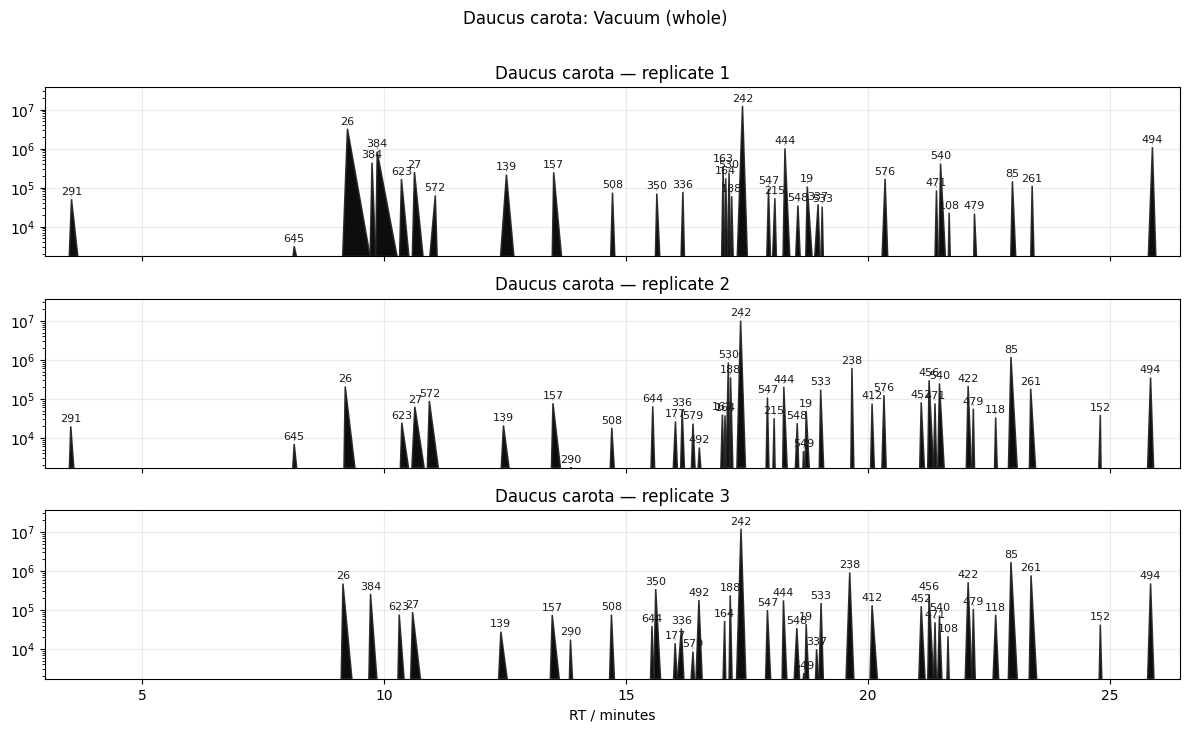

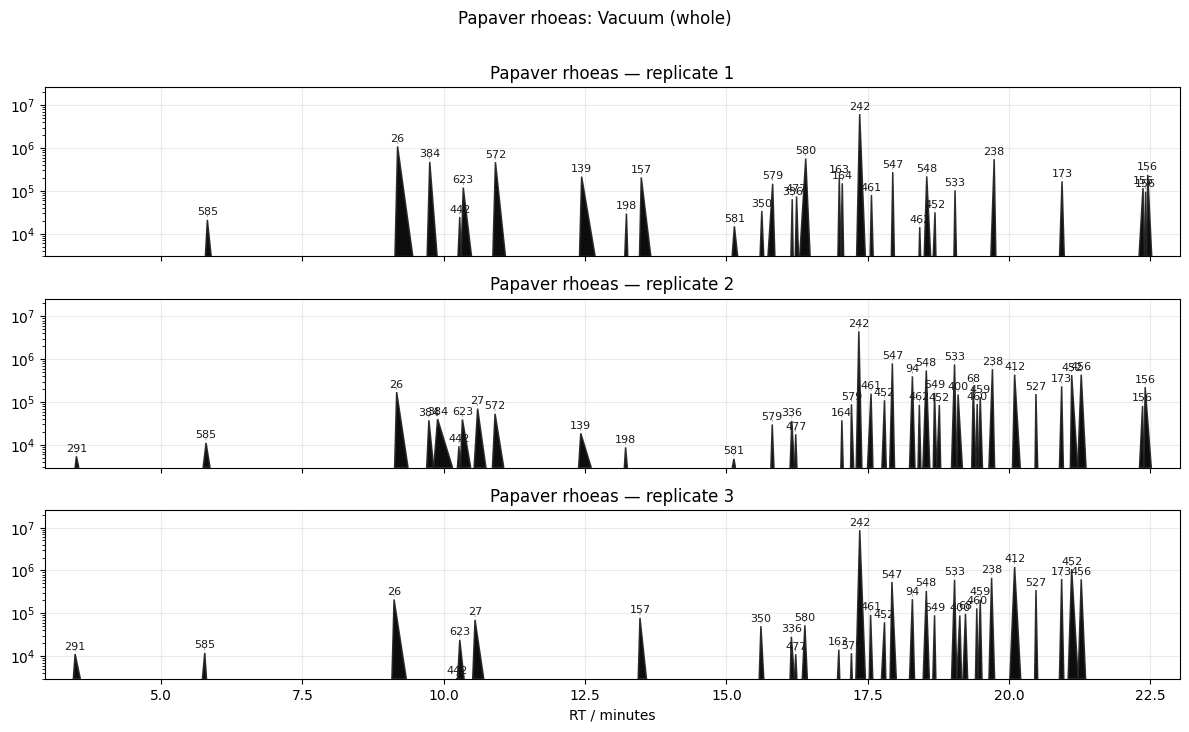

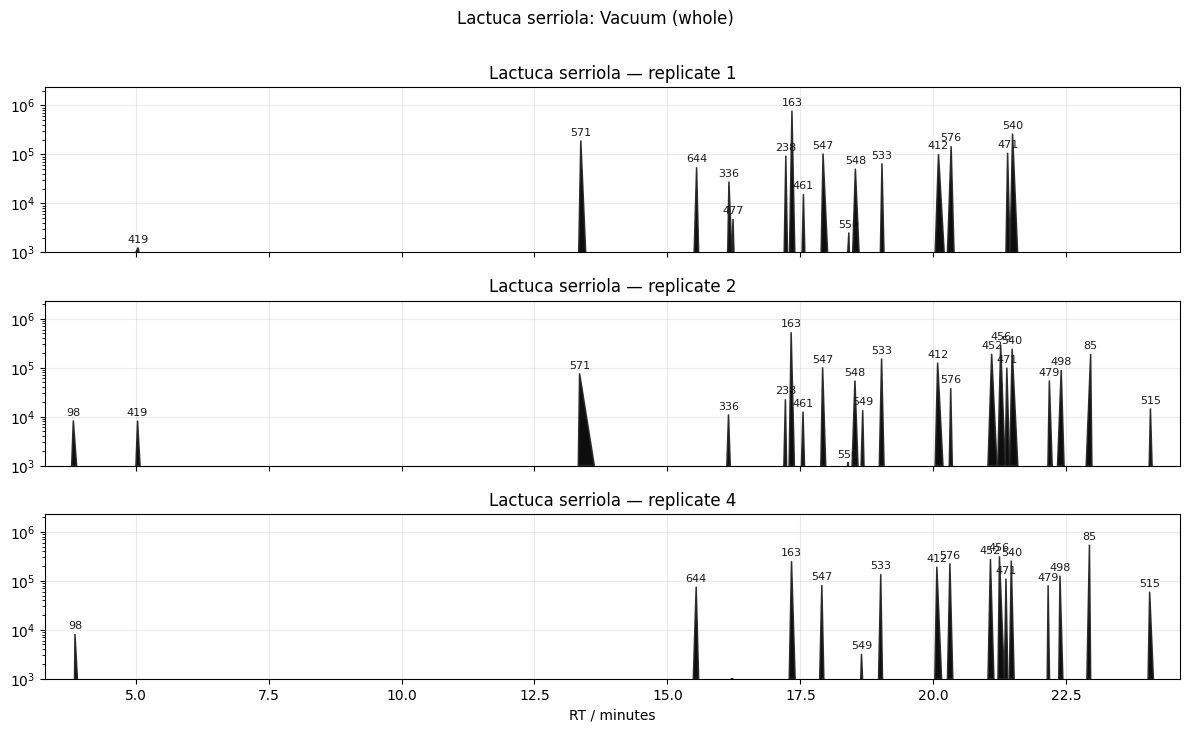

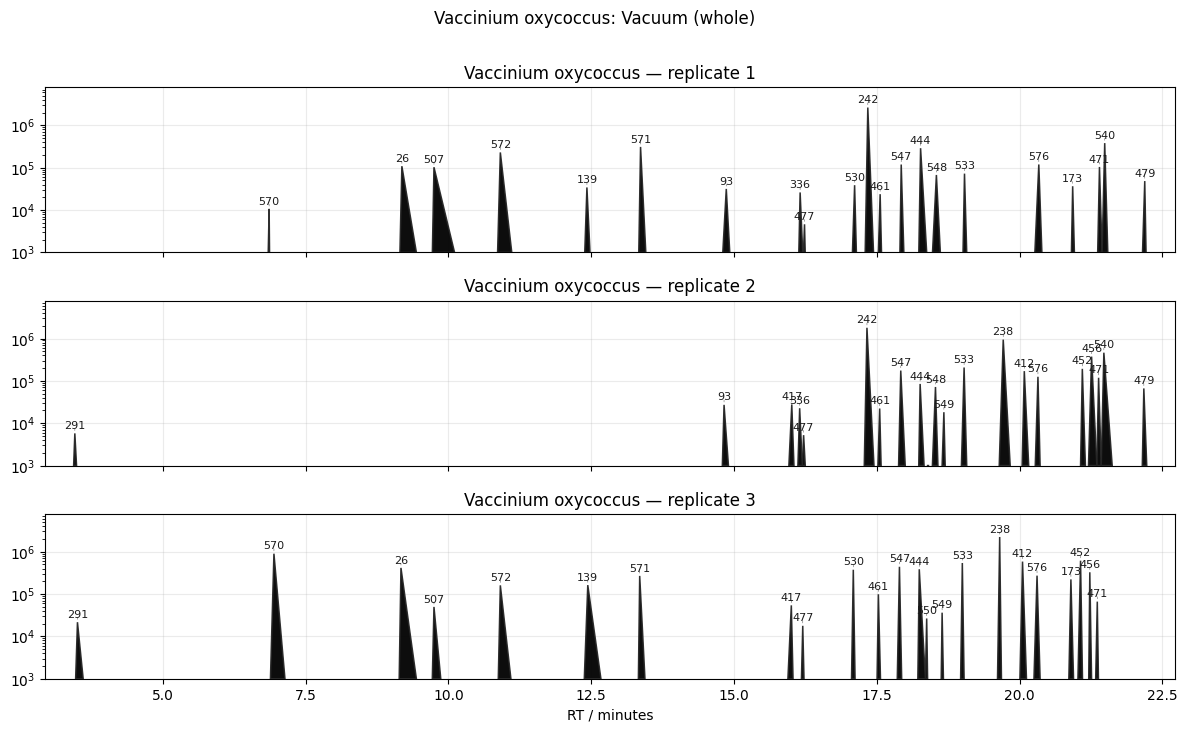

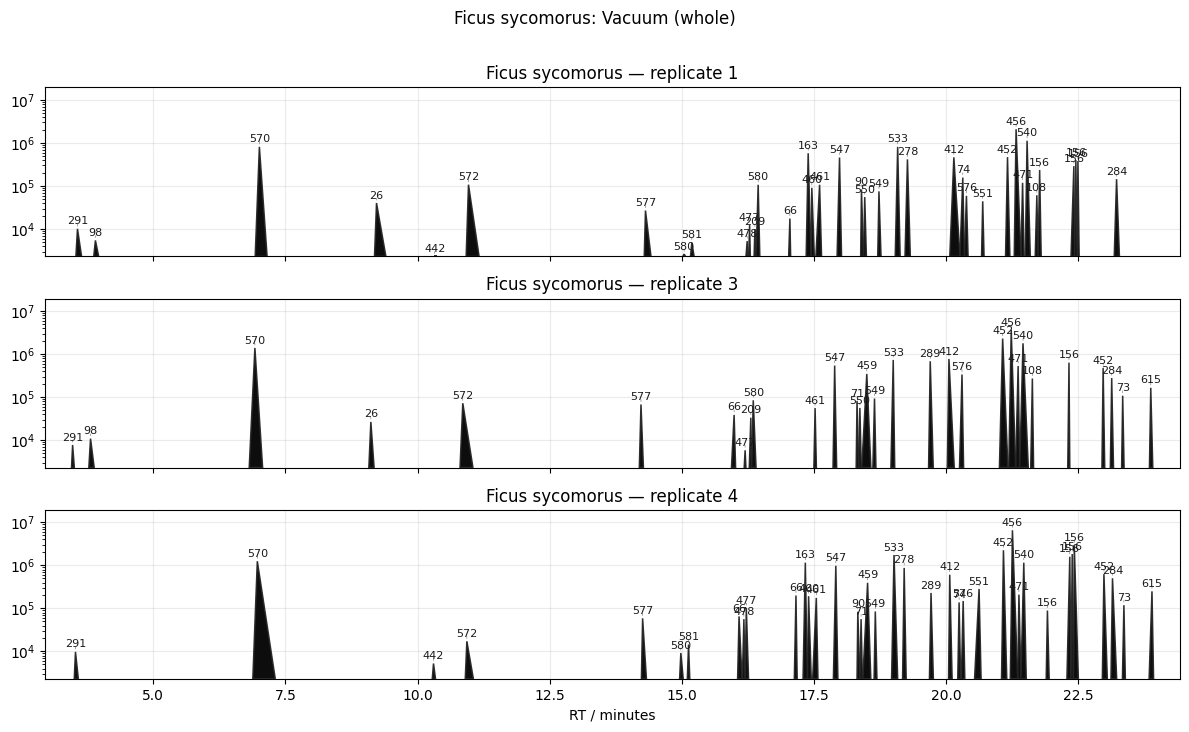

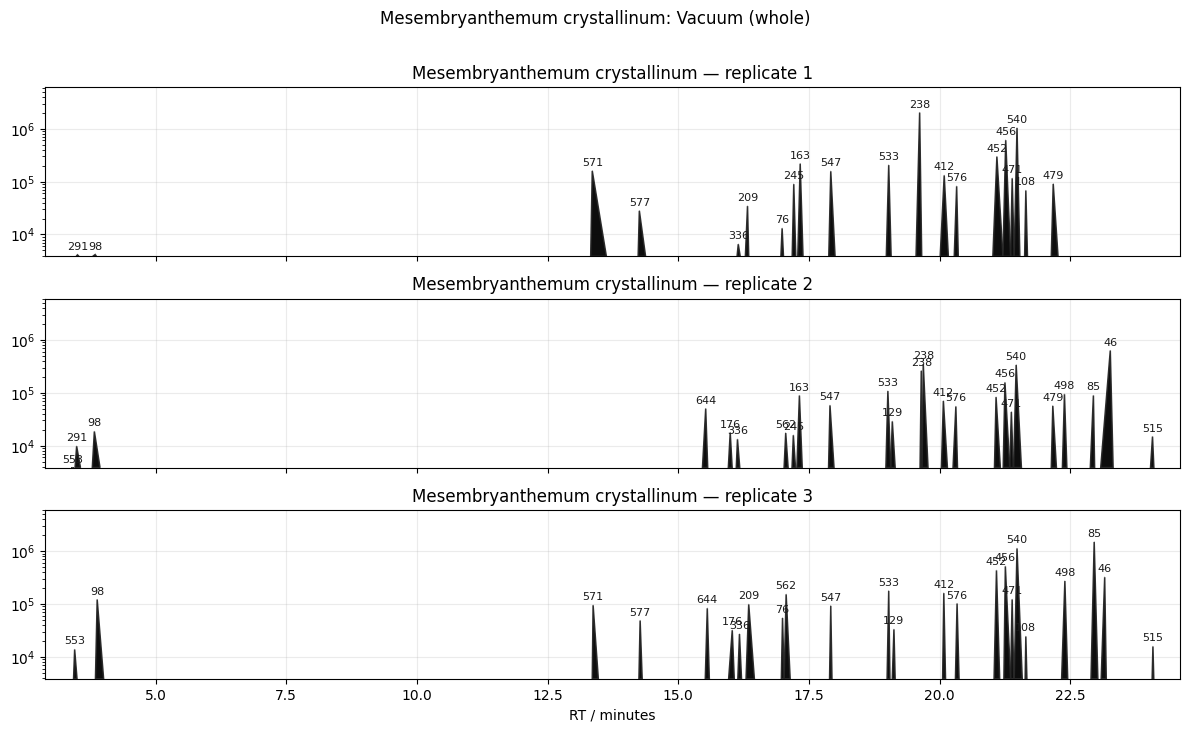

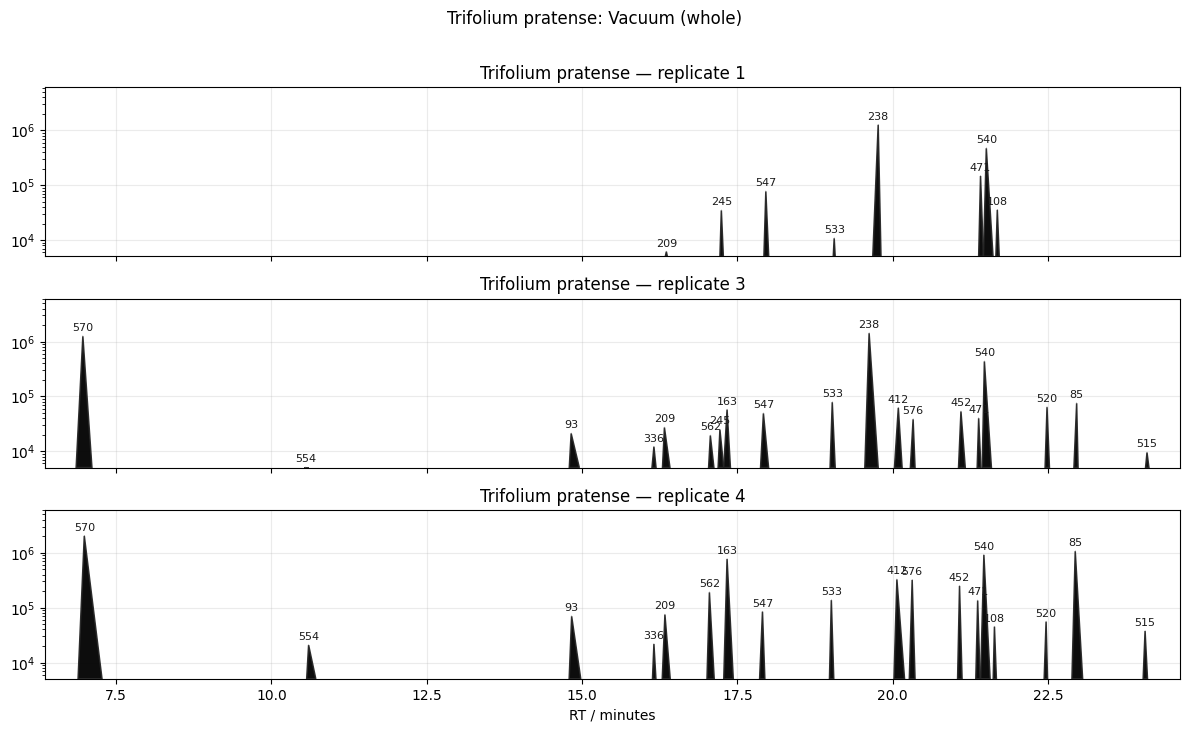

In [18]:
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Daucus carota")
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Papaver rhoeas")
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Lactuca serriola")
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Vaccinium oxycoccus")
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Ficus sycomorus")
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Mesembryanthemum crystallinum")
fig = plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_whole", species="Trifolium pratense")

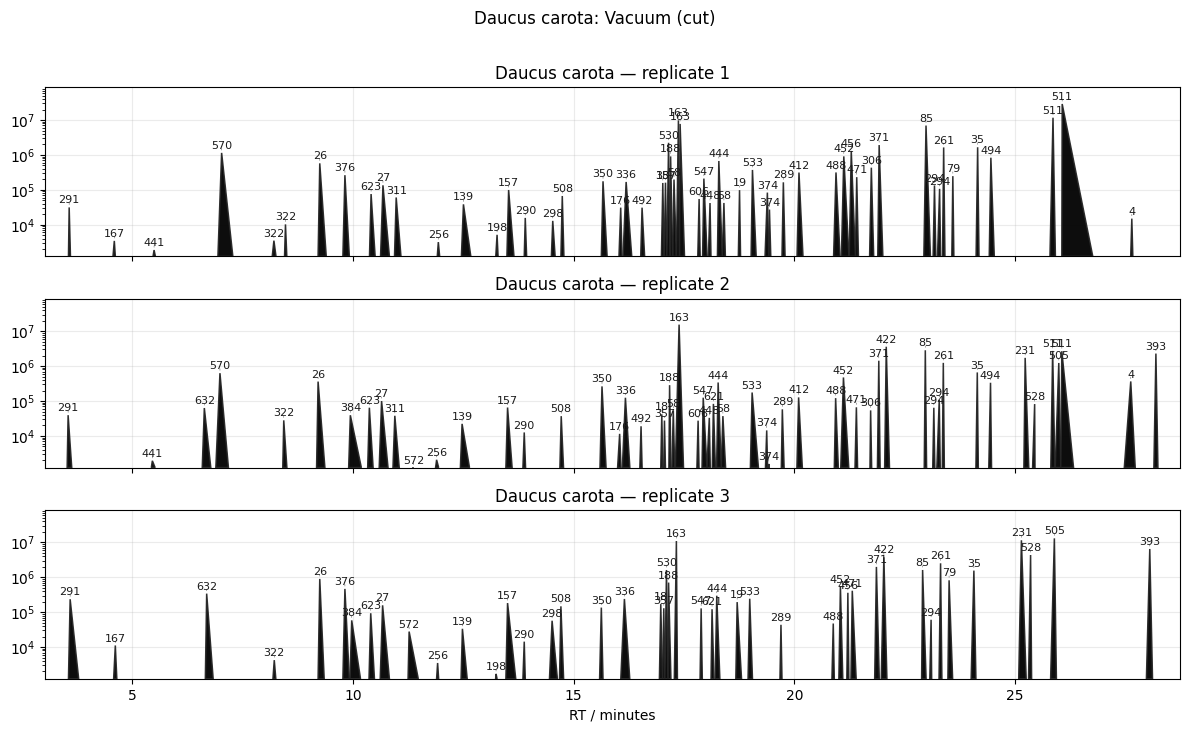

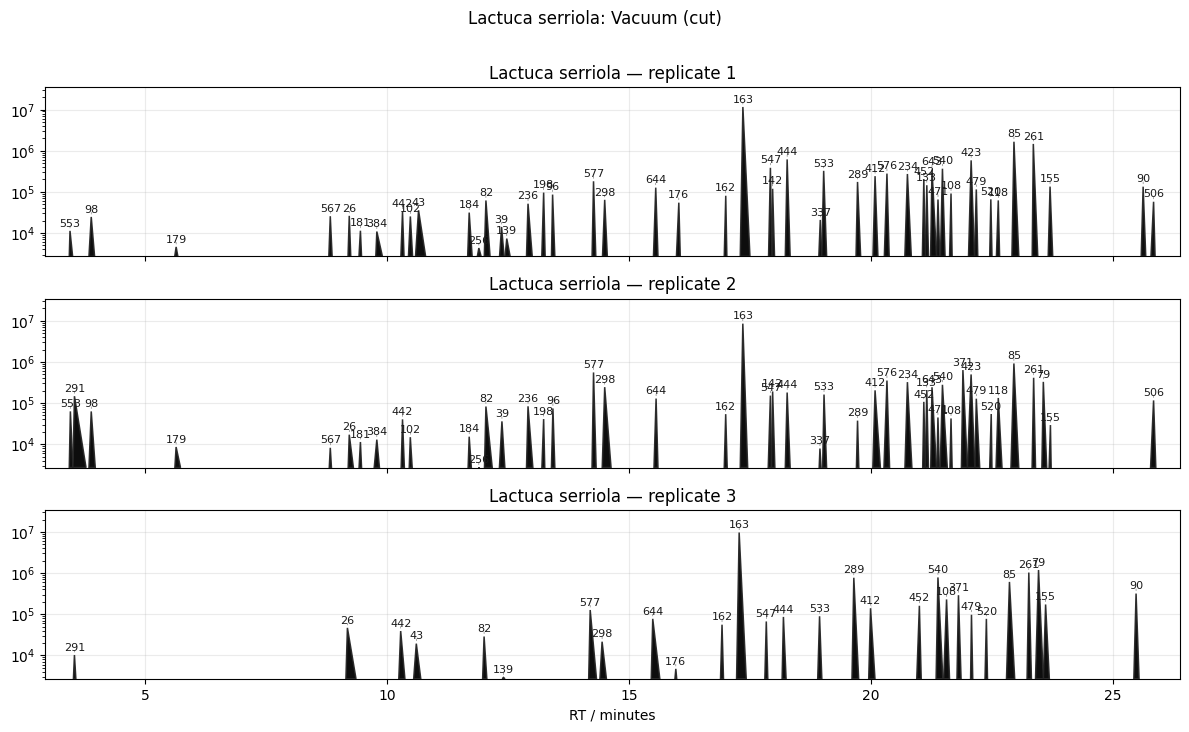

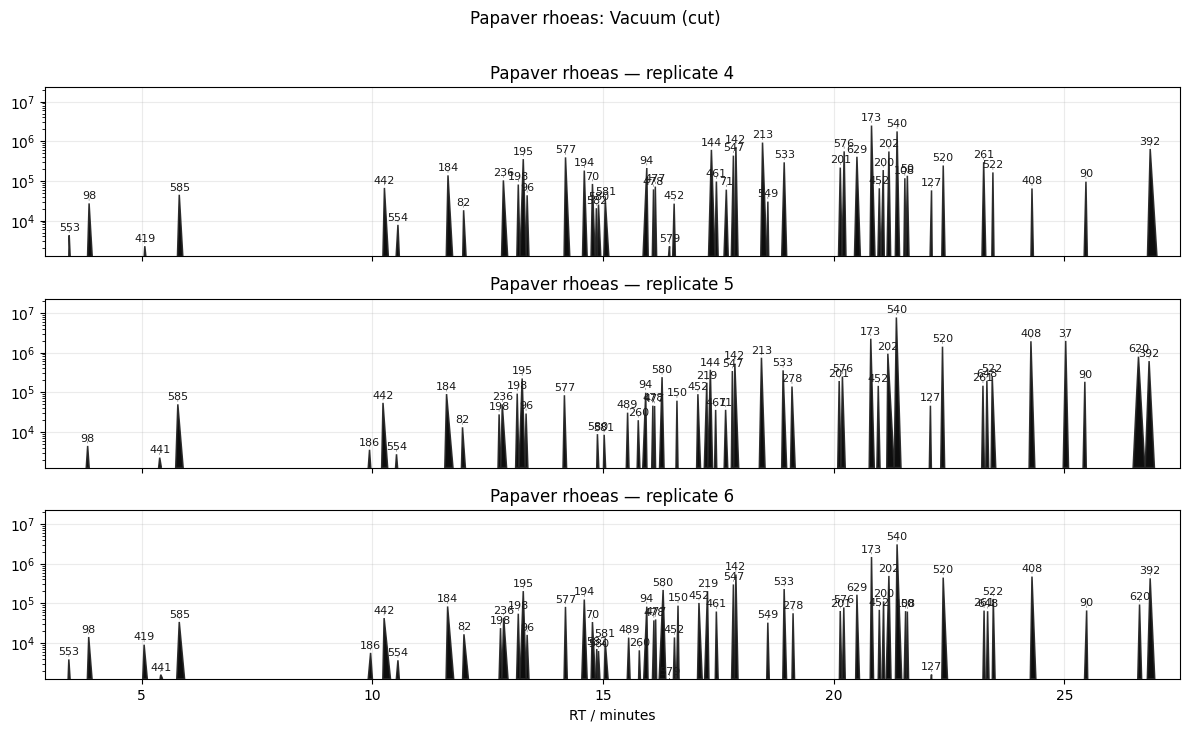

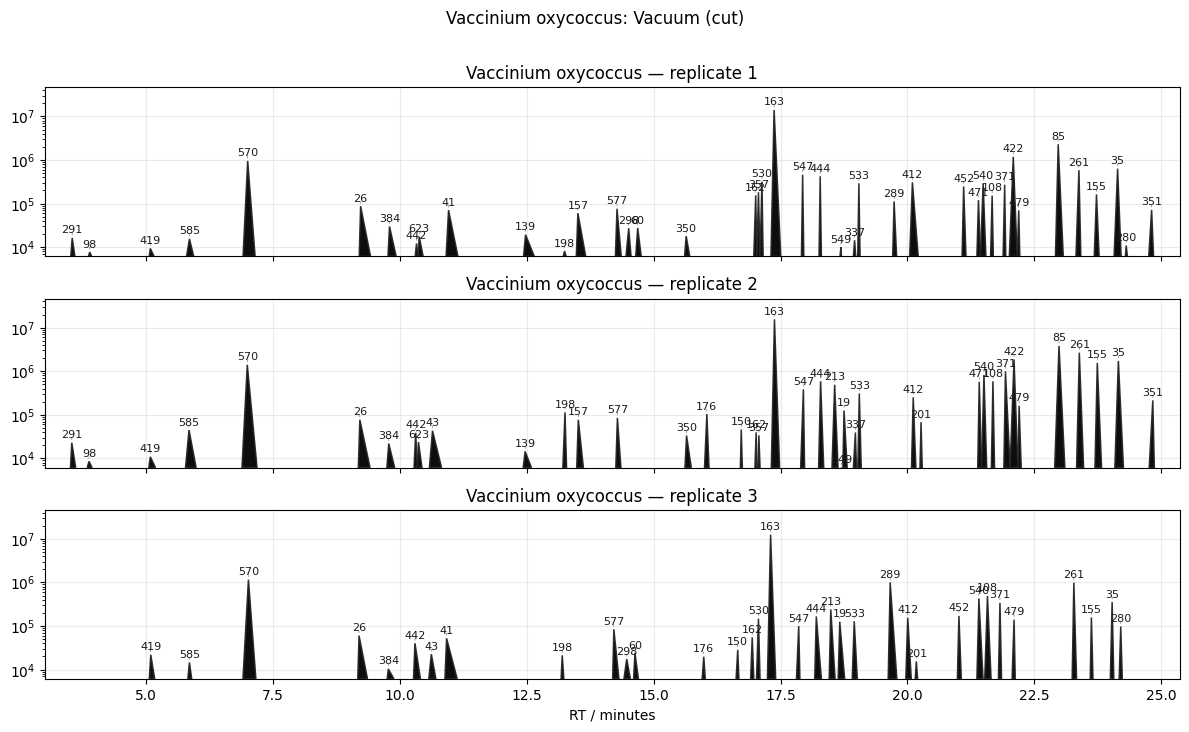

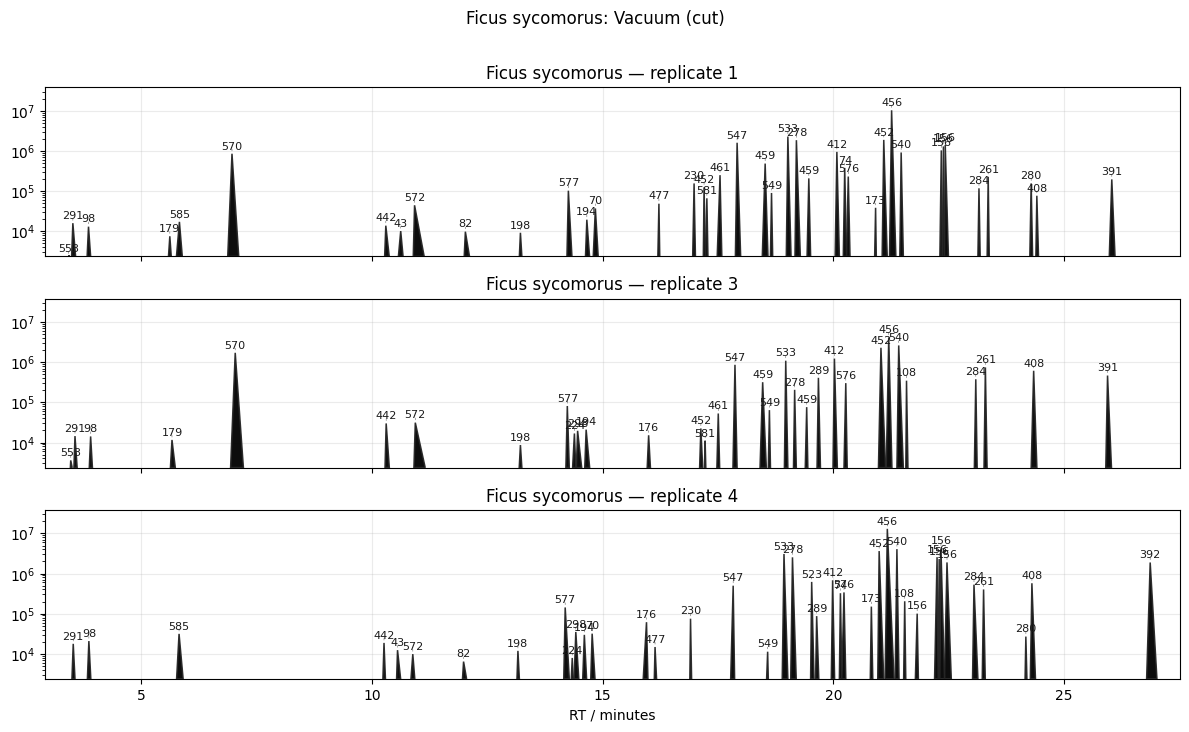

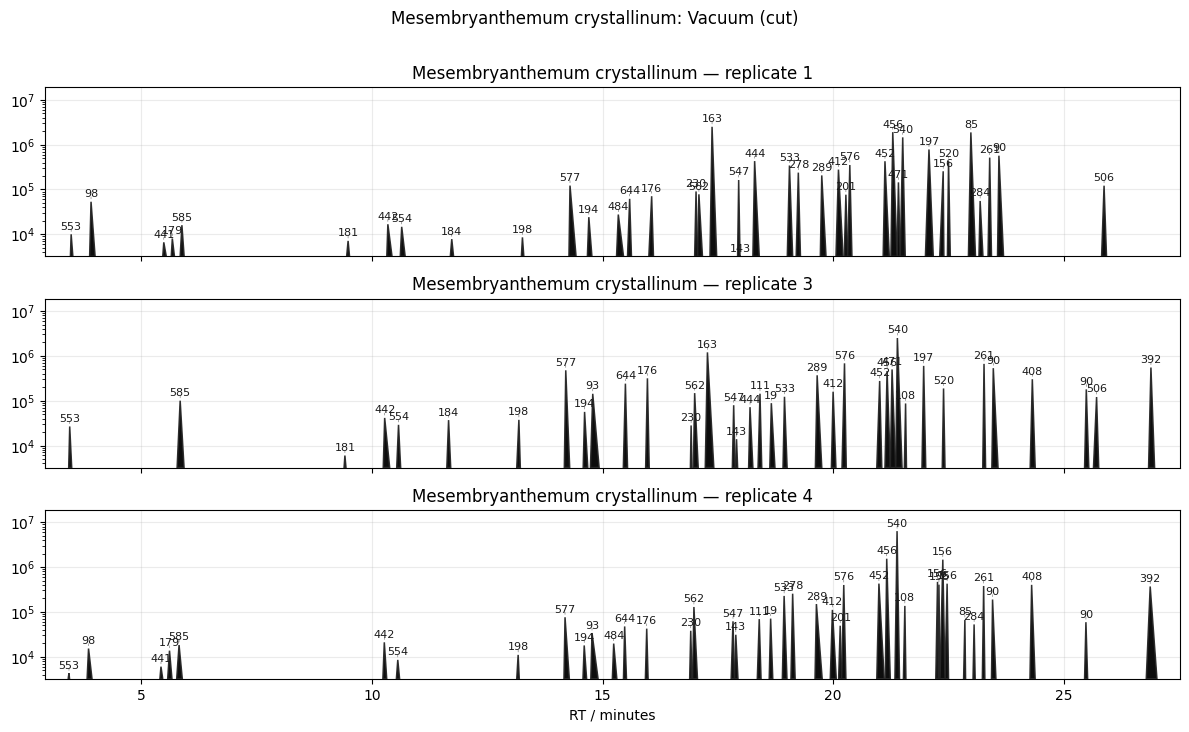

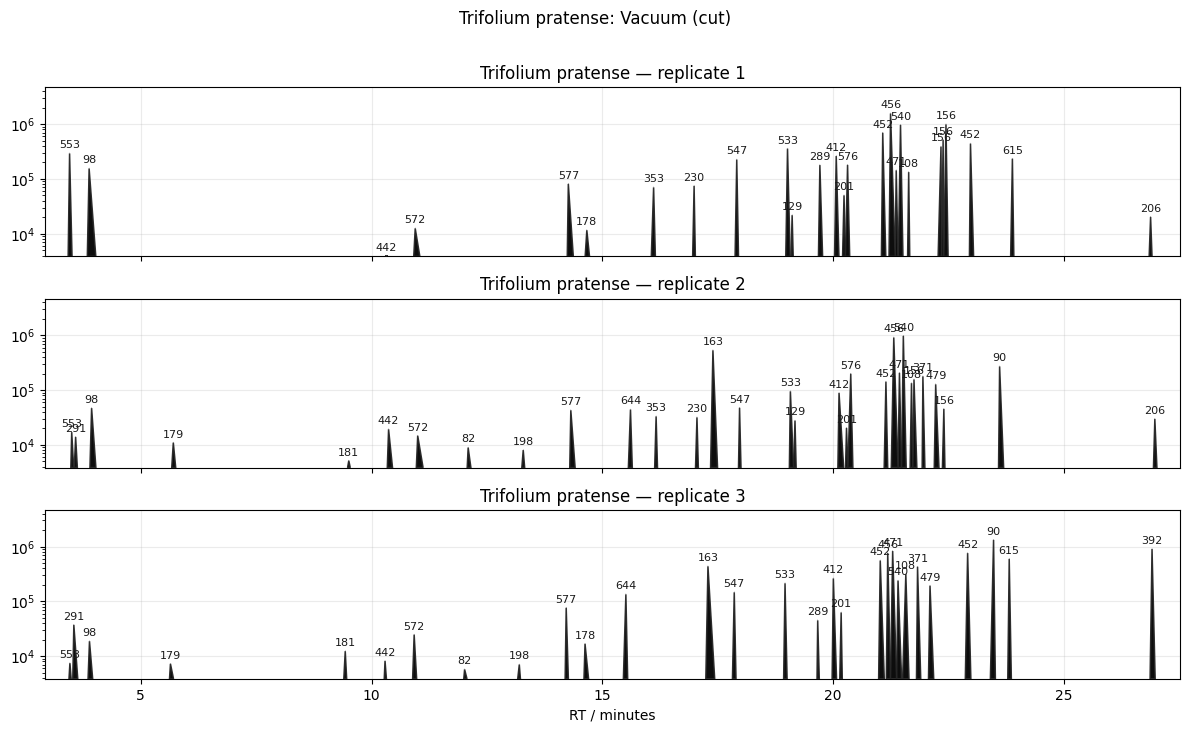

In [19]:
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Daucus carota")
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Lactuca serriola")
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Papaver rhoeas")
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Vaccinium oxycoccus")
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Ficus sycomorus")
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Mesembryanthemum crystallinum")
plot_species_peaks_by_replicate(df_filtered, treatment="vacuum_cut", species="Trifolium pratense")

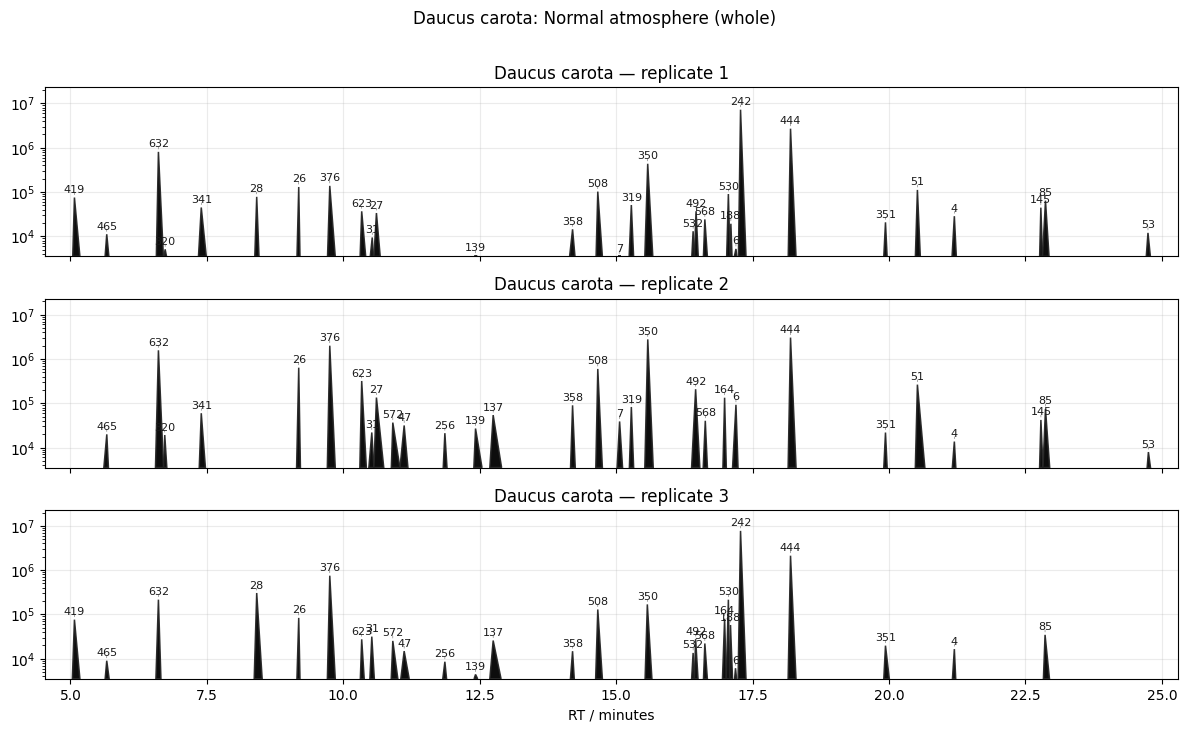

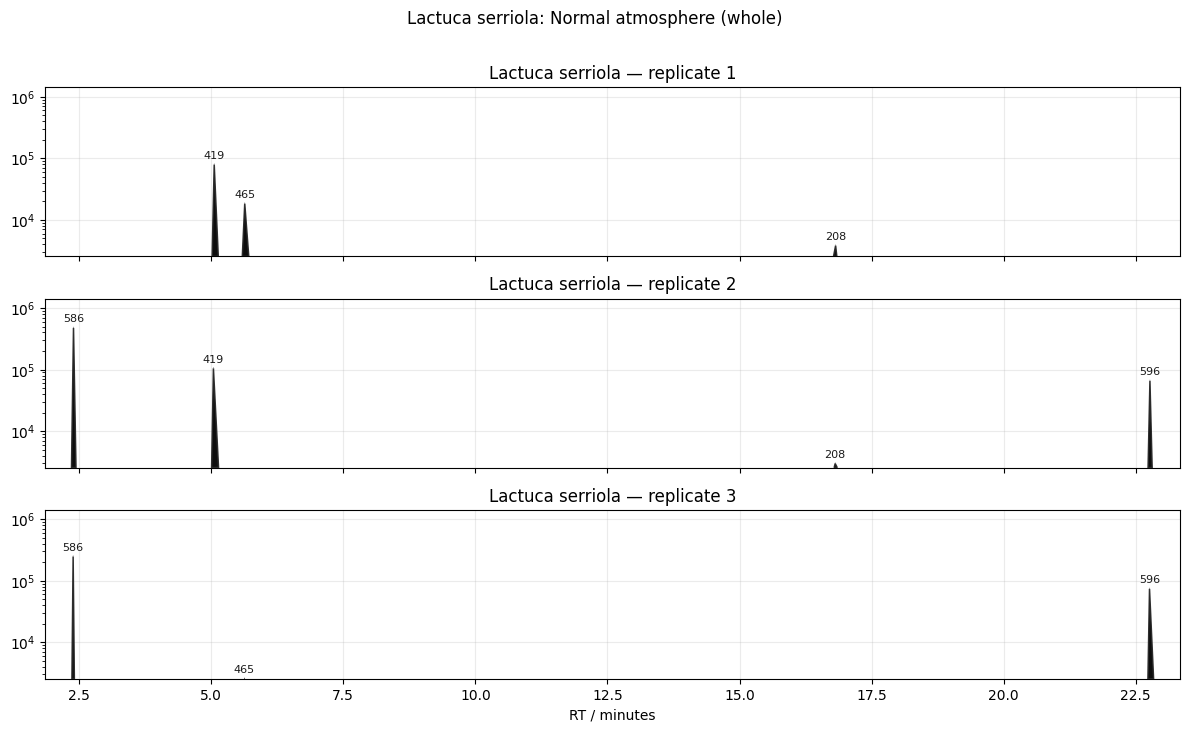

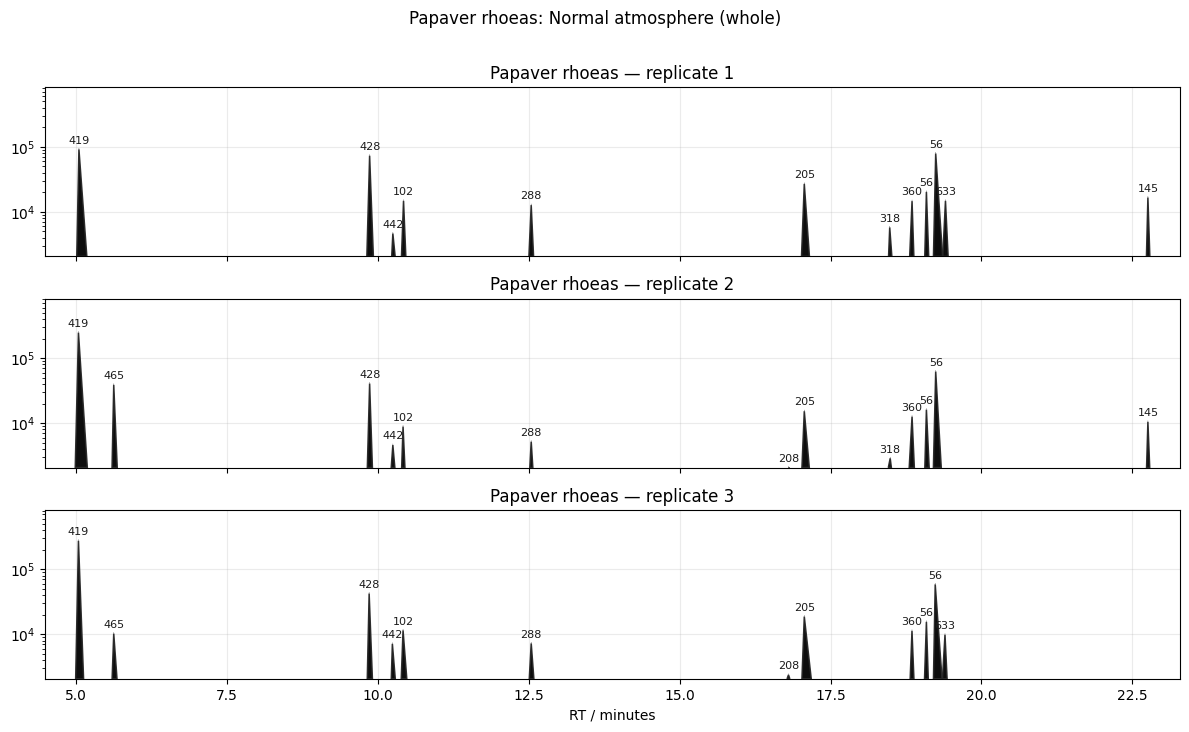

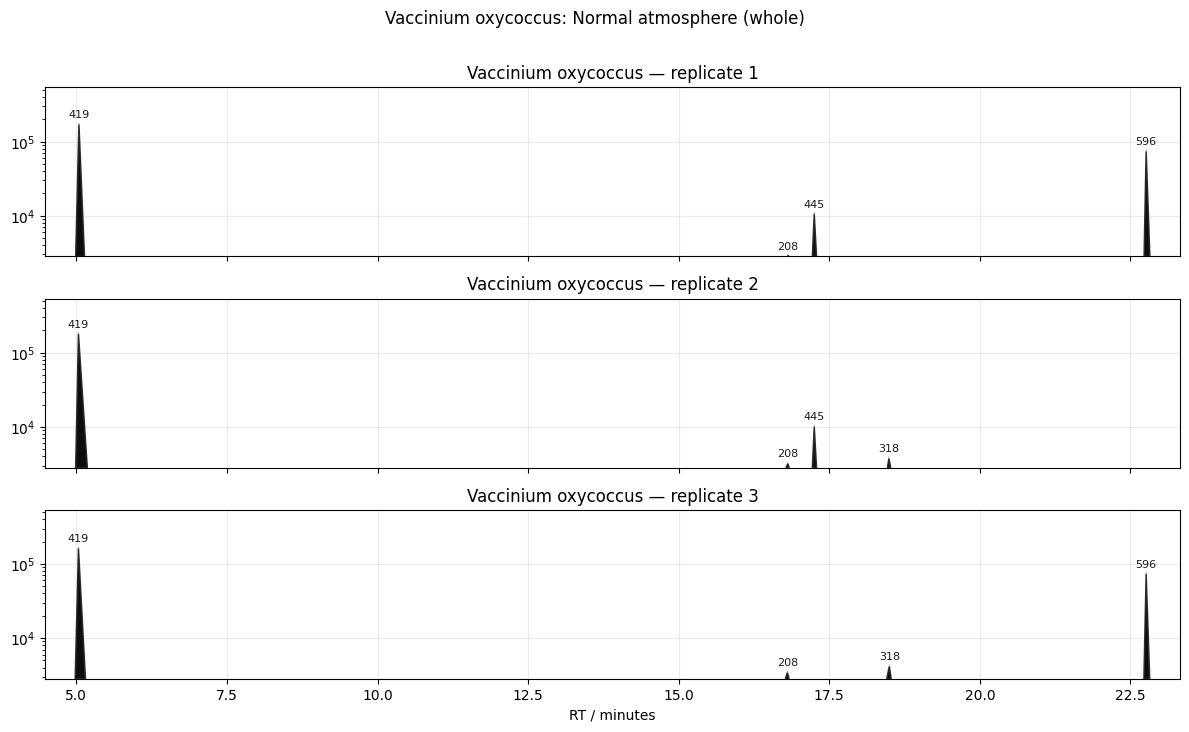

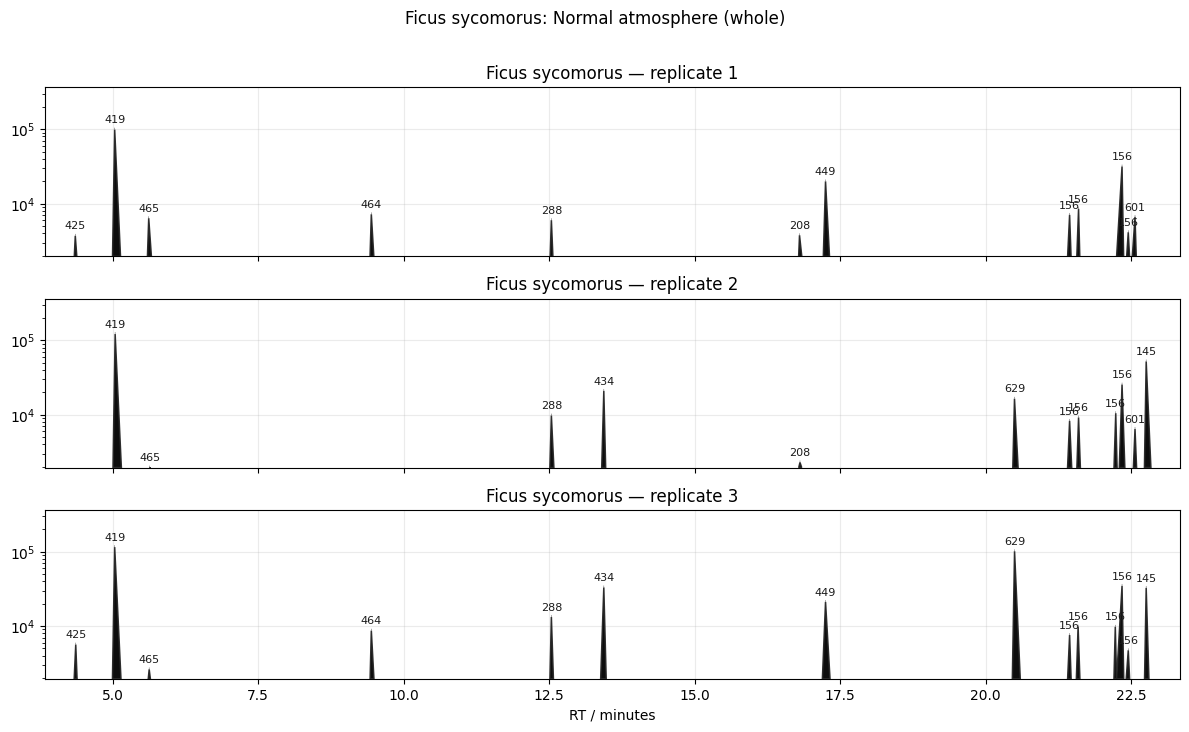

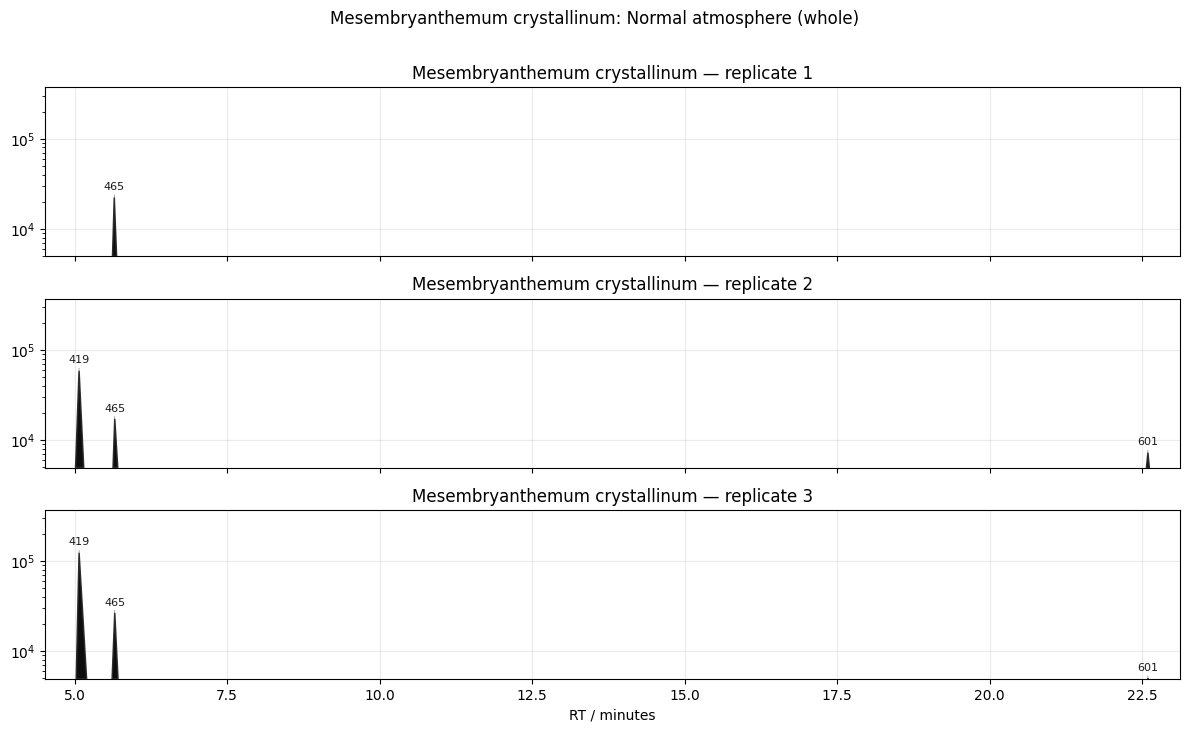

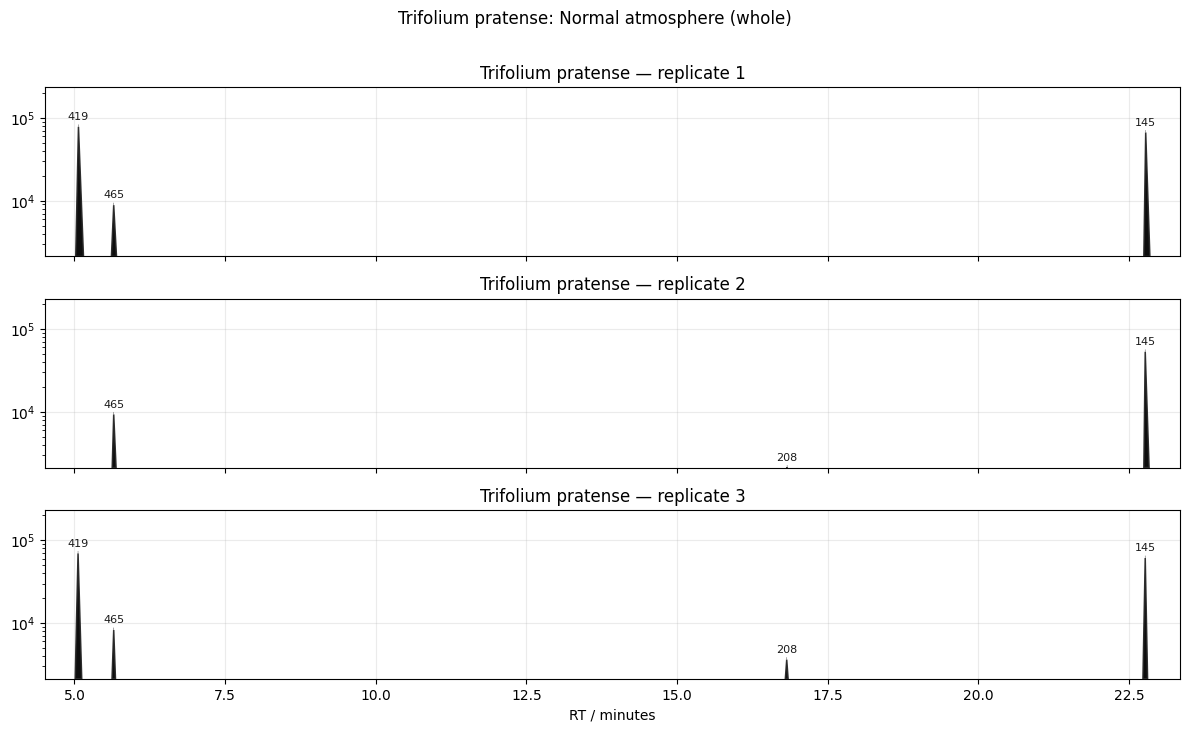

In [20]:
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Daucus carota")
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Lactuca serriola")
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Papaver rhoeas")
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Vaccinium oxycoccus")
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Ficus sycomorus")
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Mesembryanthemum crystallinum")
plot_species_peaks_by_replicate(df_filtered, treatment="normal_atm_whole", species="Trifolium pratense")

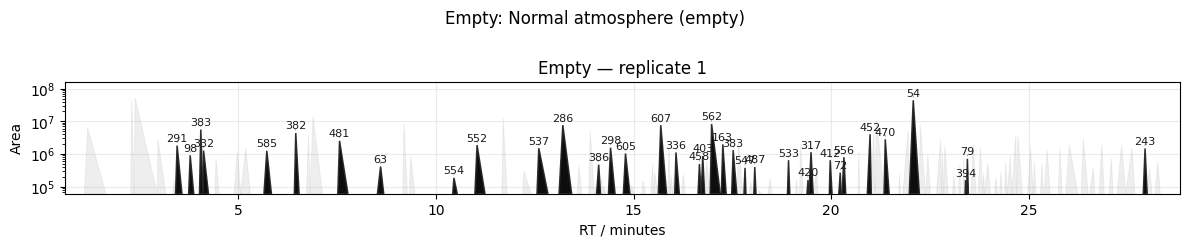

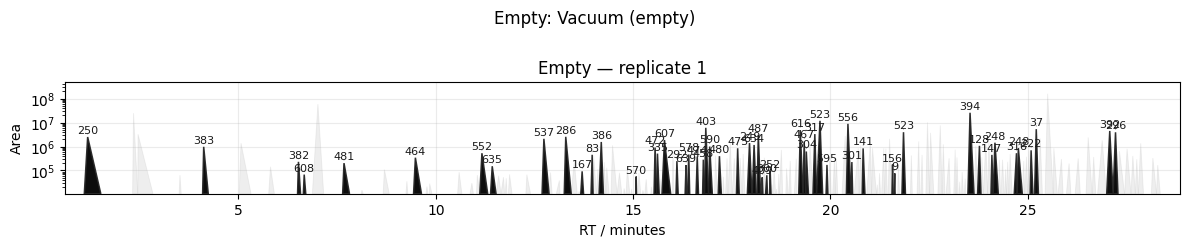

In [21]:
plot_species_peaks_by_replicate(df, treatment="normal_atm_empty", species="Empty", y_col="area")
plot_species_peaks_by_replicate(df, treatment="vacuum_empty", species="Empty", y_col="area")

In [ ]:
# drop instances of compounds that weren't ID'd in the empty data but have peaks that match signals in the seed data
ids_to_drop = [570] # oxygen
df_filtered = df_filtered[~df_filtered["compound_id"].isin(ids_to_drop)]

In [ ]:
def stacked_replicate_subplots(
    df,
    species_col="species",
    treatment_col="treatment",
    replicate_col="replicate",
    compound_col="compound_name",
    value_col="area/sample_mass",   # already normalised
    treatments=("vacuum_whole", "vacuum_cut", "normal_atm_whole"),
    treatment_labels = {
    "normal_atm_whole": "Normal atm (whole)",
    "vacuum_whole": "Vacuum (whole)",
    "vacuum_cut": "Vacuum (cut)"
    },
    top_n=20,
    lump_other=True,
    other_label="Other",
    agg="sum",  # you said "sum normalised area"
    figsize_per_species=(15, 4),
    save=False
):
    """
    For each species: 1 row of subplots (one per treatment).
    Each subplot: stacked bars across replicates, coloured by compound.
    """ 

    # --- 1) Group and aggregate ---
    if agg == "sum":
        g = (df.groupby([species_col, treatment_col, replicate_col, compound_col], dropna=False)[value_col]
               .sum()
               .reset_index())
    elif agg == "mean":
        g = (df.groupby([species_col, treatment_col, replicate_col, compound_col], dropna=False)[value_col]
               .mean()
               .reset_index())
    else:
        raise ValueError("agg must be 'sum' or 'mean'")

    # Loop species
    for sp, gsp in g.groupby(species_col, sort=False):
        gsp = gsp[gsp[treatment_col].isin(treatments)].copy()
        if gsp.empty:
            continue

        # Decide a consistent compound palette/order for THIS species.
        comp_rank = (gsp.groupby(compound_col)[value_col]
                        .sum()
                        .sort_values(ascending=False))
        keep = comp_rank.index[:top_n].tolist()

        fig, axes = plt.subplots(1, len(treatments), figsize=figsize_per_species, sharey=True)

        # ---- Colour map ----
        base_comps = keep.copy()
        n = len(base_comps)

        cmap = plt.get_cmap("turbo")
        base_colors = cmap(np.linspace(0, 1, n))
        colors = {c: col for c, col in zip(base_comps, base_colors)}

        if lump_other:
            colors[other_label] = "lightgray"

        # ---- NEW: hatch map (consistent across treatments for this species) ----
        # pick a set of hatches; repeats if top_n > len(hatches)
        hatches = ['//', '\\\\', 'xx', '..', 'oo', '--', '||', '++', '**', 'OO', 'o', 'x', '/']
        hatch_map = {c: hatches[i % len(hatches)] for i, c in enumerate(keep)}
        if lump_other:
            hatch_map[other_label] = ''  # or '...' if you want Other hatched too

        if len(treatments) == 1:
            axes = [axes]

        for ax, t in zip(axes, treatments):
            gt = gsp[gsp[treatment_col] == t].copy()

            reps = gt[replicate_col].dropna().unique().tolist()
            try:
                reps = sorted(reps)
            except Exception:
                pass

            if lump_other:
                gt[compound_col] = np.where(gt[compound_col].isin(keep), gt[compound_col], other_label)
                gt = (gt.groupby([replicate_col, compound_col], dropna=False)[value_col]
                        .sum()
                        .reset_index())
            else:
                gt = (gt.groupby([replicate_col, compound_col], dropna=False)[value_col]
                        .sum()
                        .reset_index())

            wide = (gt.pivot_table(index=replicate_col, columns=compound_col, values=value_col, fill_value=0.0)
                      .reindex(reps, fill_value=0.0))

            cols = [c for c in keep if c in wide.columns]
            if lump_other and other_label in wide.columns:
                cols += [other_label]
            else:
                cols = wide.sum(axis=0).sort_values(ascending=False).index.tolist()

            wide = wide.reindex(columns=cols, fill_value=0.0)

            # --- 2) Plot stacked bars ---
            x = np.arange(len(wide.index))
            bottoms = np.zeros(len(wide.index))

            for c in wide.columns:
                ax.bar(
                    x,
                    wide[c].values,
                    bottom=bottoms,
                    label=c,
                    color=colors.get(c, "lightgray"),
                    hatch=hatch_map.get(c, ''),     # NEW
                    edgecolor="black",              # NEW (makes hatch readable)
                    linewidth=0.3,                  # NEW (subtle)
                )
                bottoms += wide[c].values

            ax.set_title(treatment_labels.get(t, t))
            ax.set_xticks(x)
            ax.set_xticklabels([f"{int(r)}" for r in wide.index])
            ax.set_xlabel("Replicate")
            ax.set_ylabel("Area / sample mass")
            ax.grid(axis="y", alpha=0.25)

        # Legend: hatches will show automatically because they’re on the patches

        # Collect legend entries from ALL subplots
        handles_labels = [ax.get_legend_handles_labels() for ax in axes]
        handles = sum((hl[0] for hl in handles_labels), [])
        labels  = sum((hl[1] for hl in handles_labels), [])

        # Remove duplicates (preserve first occurrence)
        seen = set()
        handles_unique, labels_unique = [], []
        for h, lab in zip(handles, labels):
            if lab not in seen:
                seen.add(lab)
                handles_unique.append(h)
                labels_unique.append(lab)

        # ---- Enforce consistent order: keep then Other ----
        desired = [c for c in keep]
        if lump_other and other_label in labels_unique:
            desired += [other_label]

        order = {lab: i for i, lab in enumerate(desired)}

        pairs = sorted(
            zip(labels_unique, handles_unique),
            key=lambda p: order.get(p[0], 10**9)
        )

        if pairs:
            labels_unique, handles_unique = zip(*pairs)
        else:
            labels_unique, handles_unique = [], []

        fig.legend(
            handles_unique,
            labels_unique,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False
        )

        fig.suptitle(str(sp), y=1.02)

        # ---- Save figure if requested ----
        if save:
            safe_sp = str(sp).replace(" ", "_").replace("/", "_")
            fig.savefig(
                f"Plots/{safe_sp}_replicate_variability.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()
        plt.close()


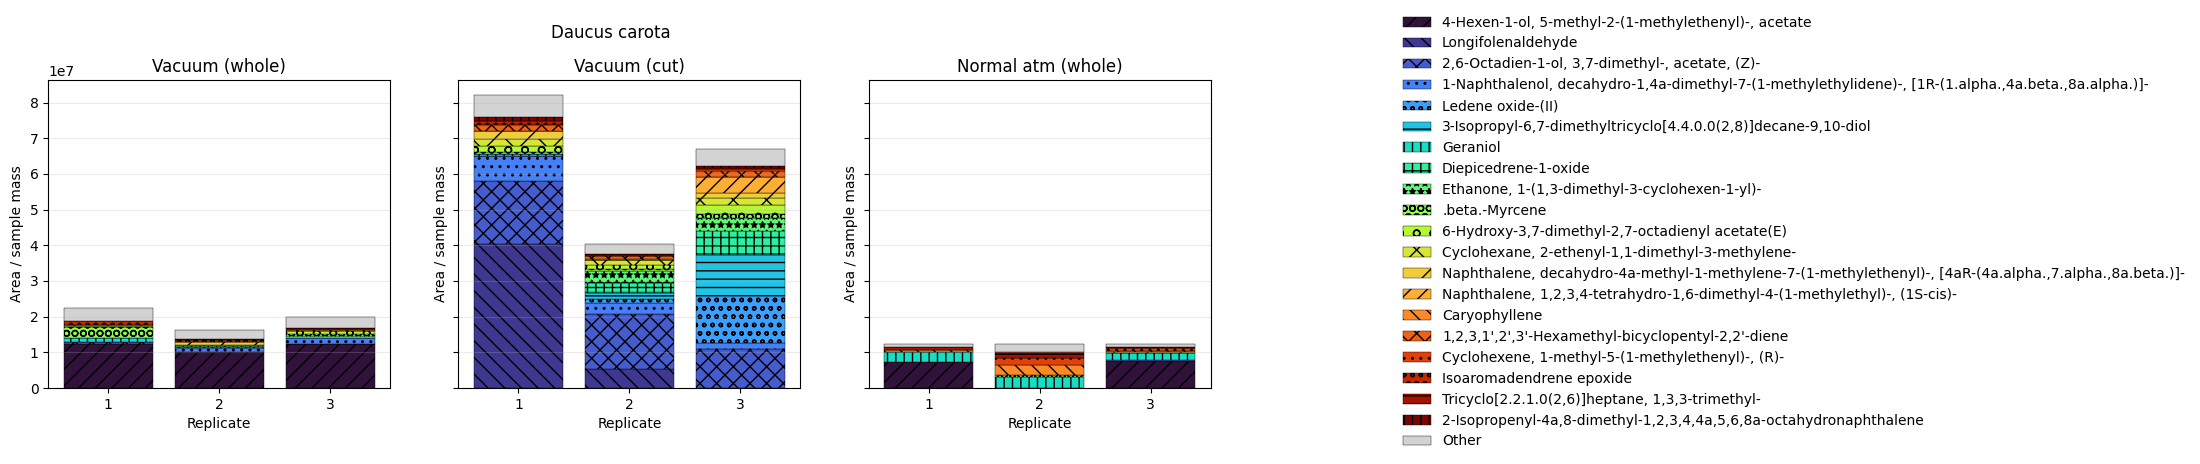

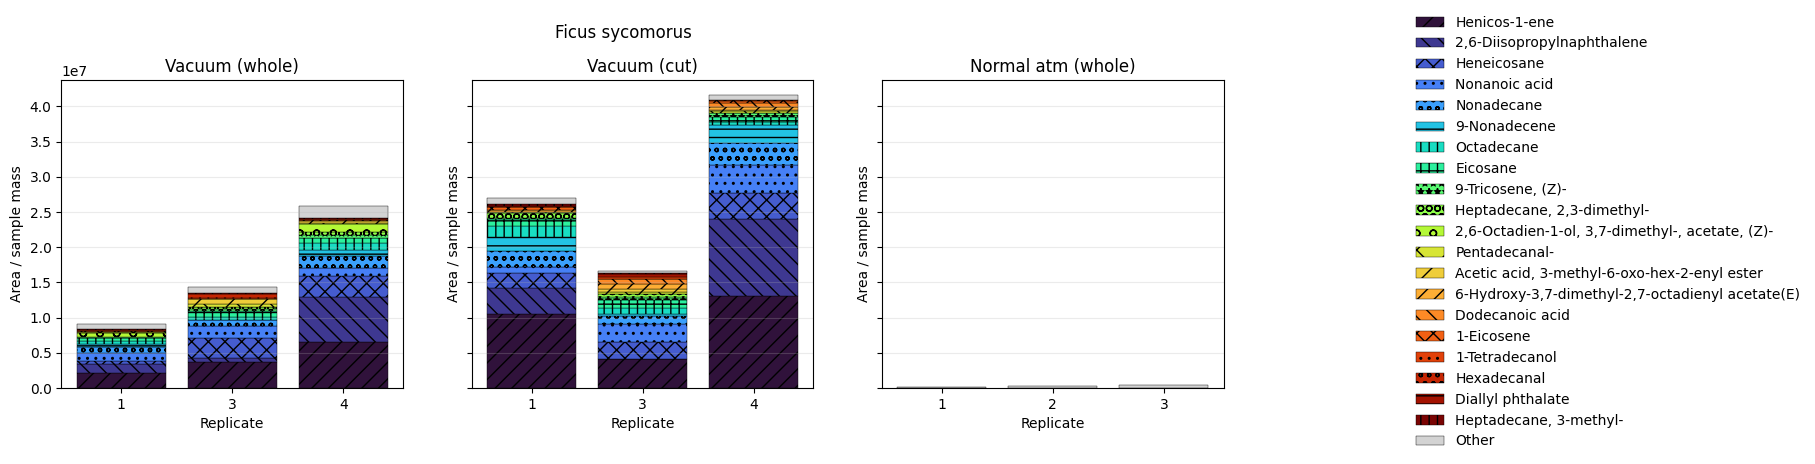

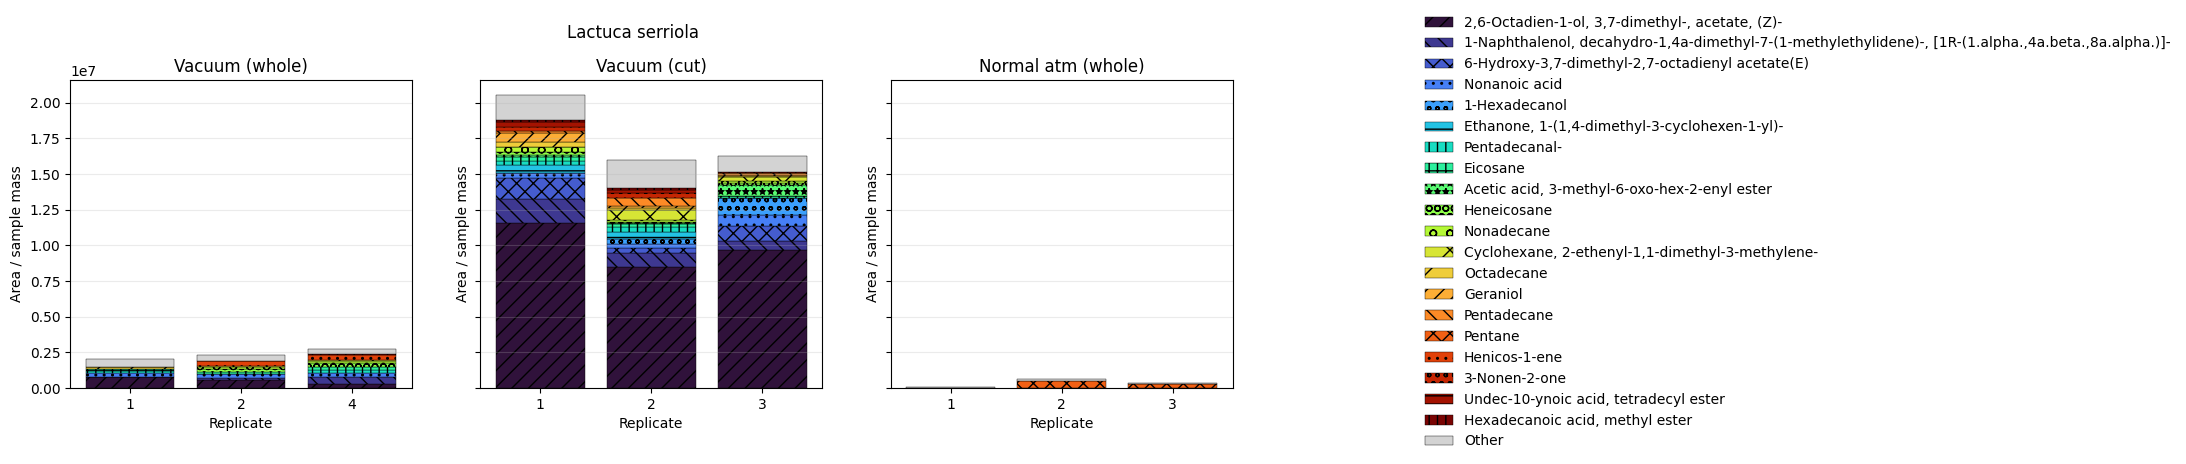

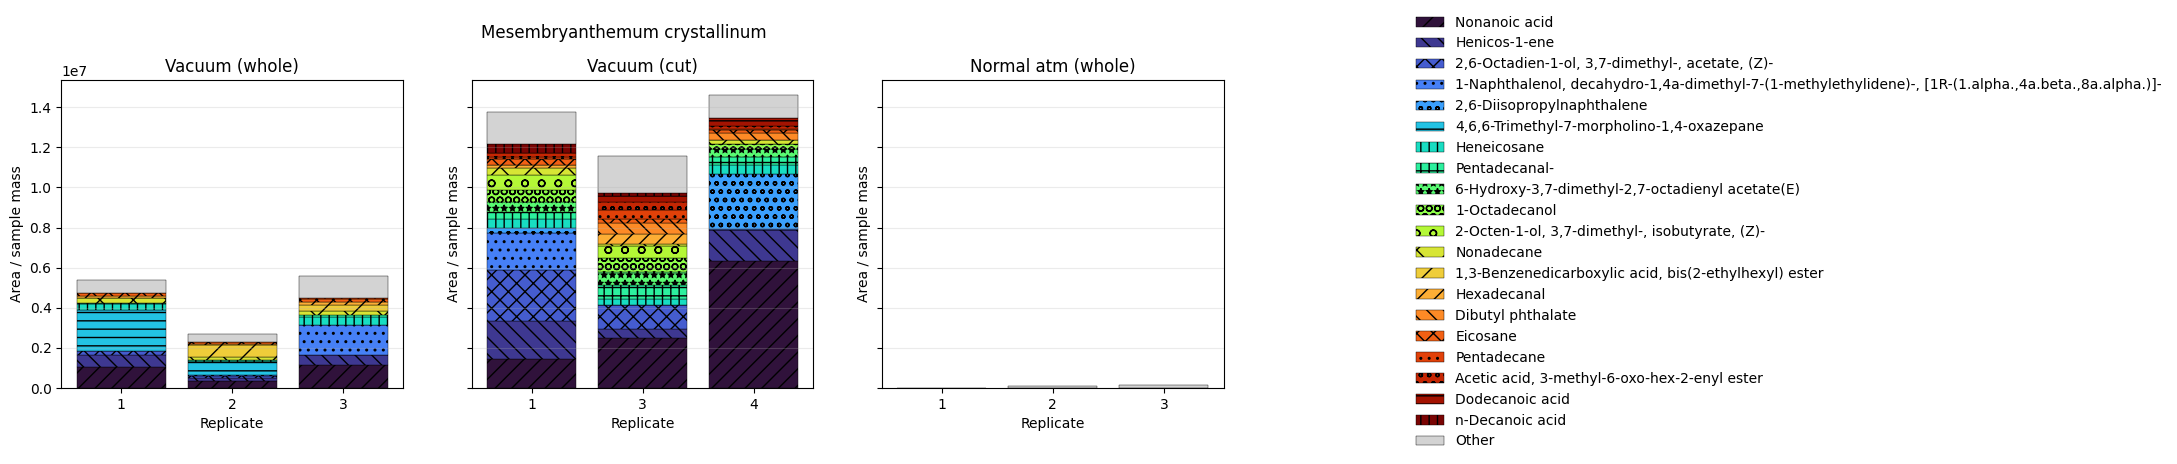

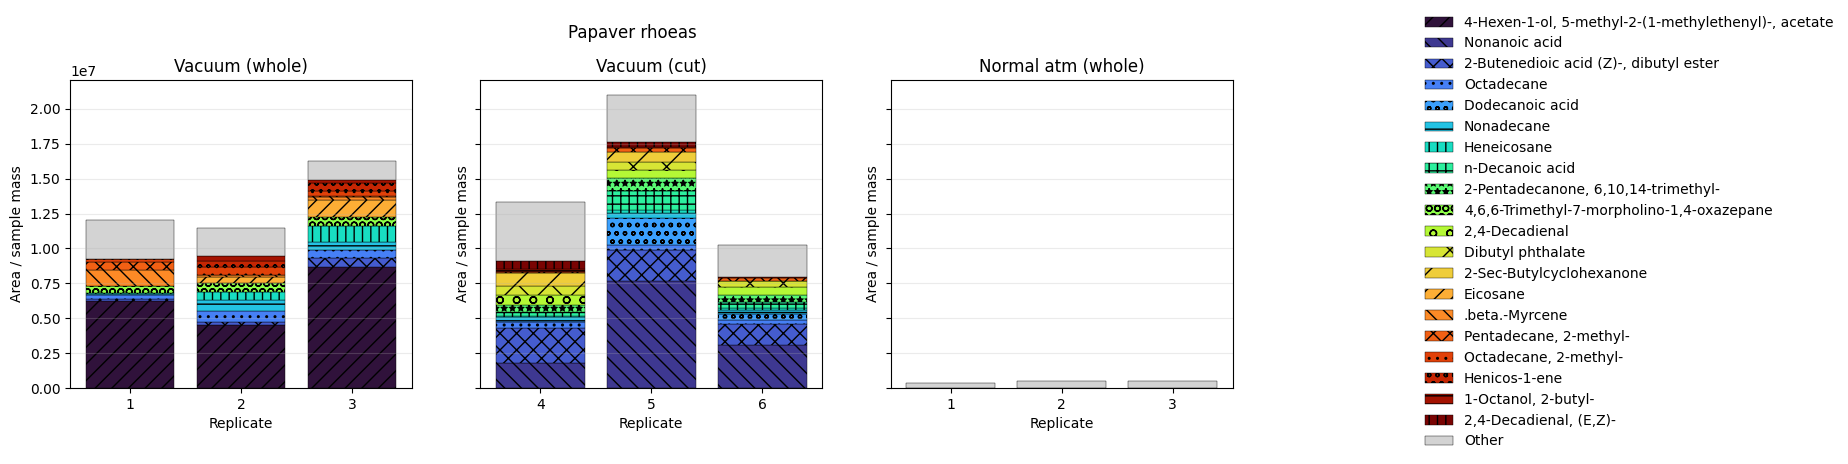

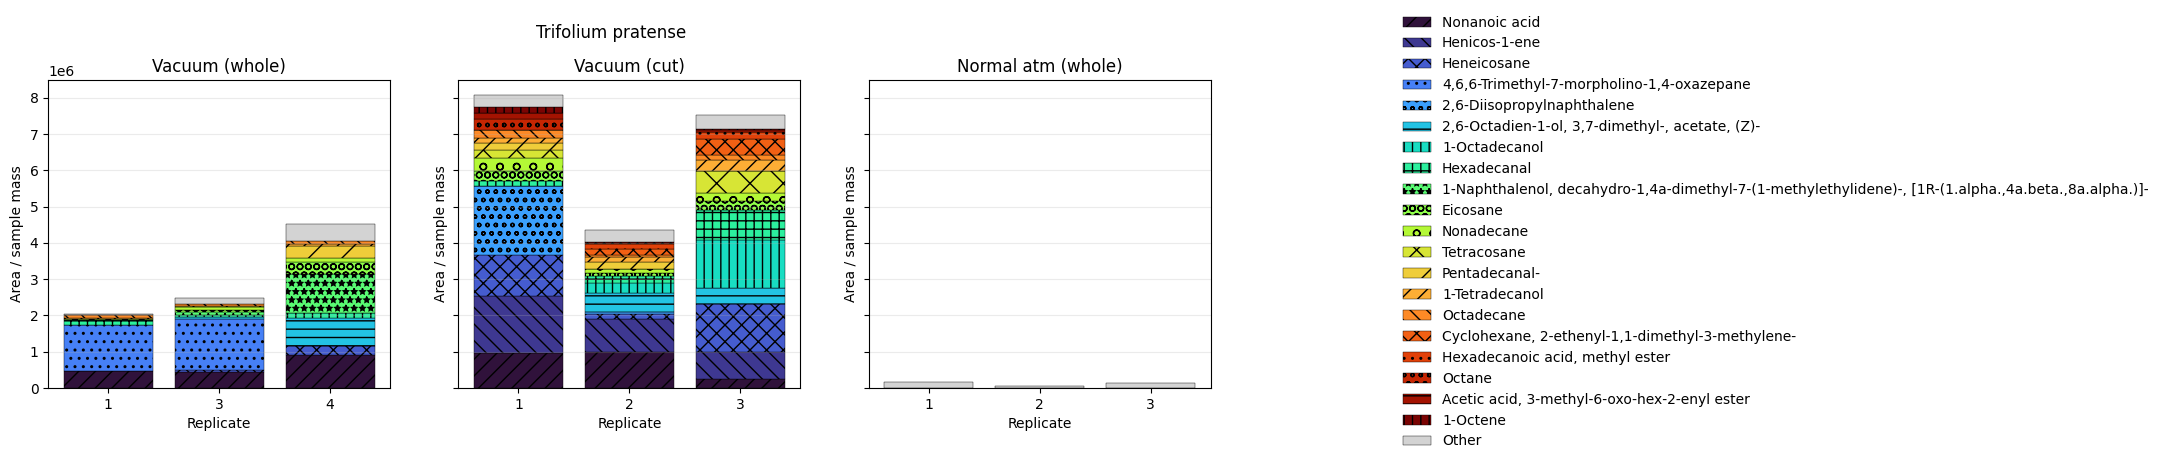

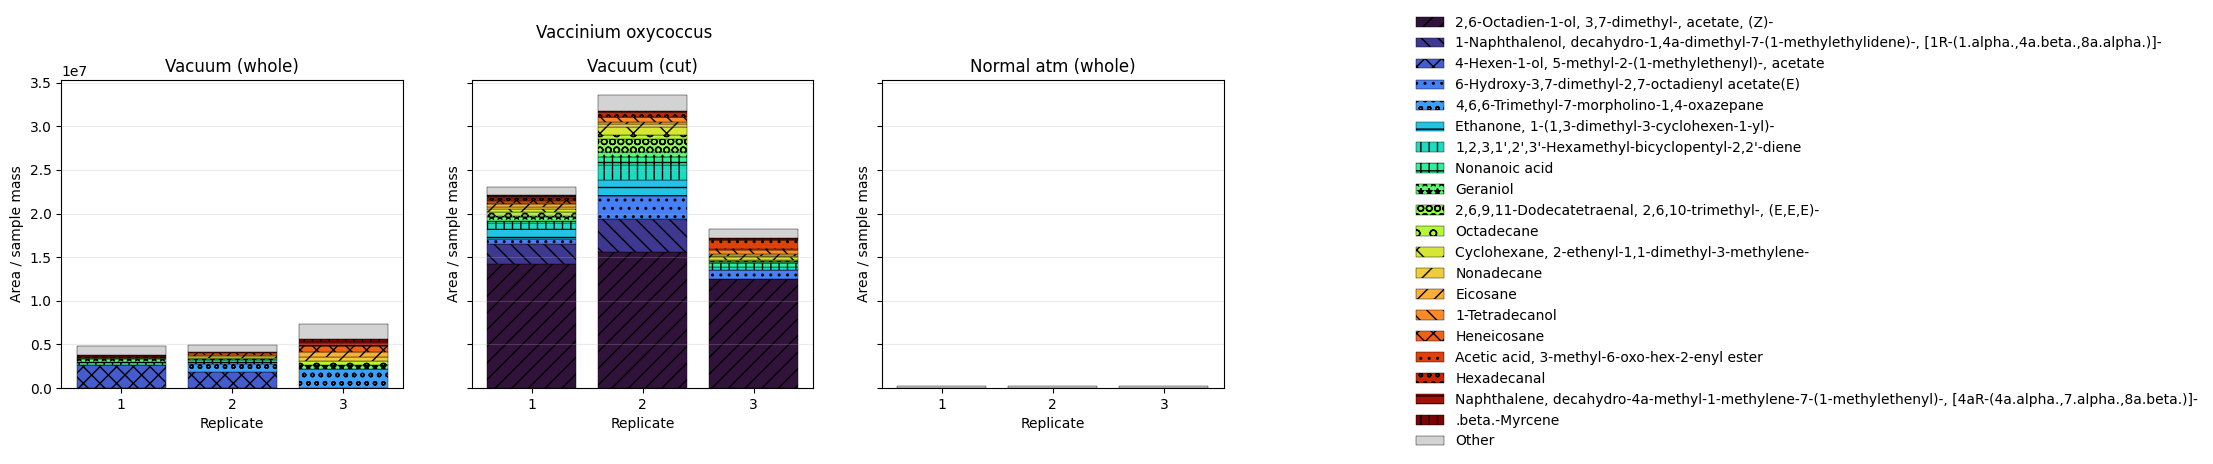

In [23]:
stacked_replicate_subplots(df_filtered, save=False)

In [26]:
df_filtered.to_csv('filtered_gc-ms_data.csv',index=False)

In [34]:
def compound_presence_tables(
    df,
    species_col="species",
    treatment_col="treatment",
    compound_col="compound_name",
    treatments=None,
    drop_empty_species=True,
    empty_label="Empty",
):
    """
    Construct presence/absence tables (one per treatment).

    Returns:
        dict of:
            treatment -> {
                "table": plain DataFrame,
                "styled": styled DataFrame (green/red cells)
            }
    """

    results = {}

    # Optionally remove empty vial species
    if drop_empty_species:
        df = df[df[species_col] != empty_label]

    # Determine treatments automatically if not provided
    if treatments is None:
        treatments = df[treatment_col].unique()

    for treatment in treatments:

        sub = df[df[treatment_col] == treatment]

        # Remove duplicate compound/species combinations
        sub_unique = (
            sub[[compound_col, species_col]]
            .drop_duplicates()
        )

        species_in_df = sorted(df[species_col].dropna().unique().tolist())
        # Default order (alphabetical)
        species_order = species_in_df

        # Create presence/absence pivot table
        presence = (
            sub_unique.assign(present="yes")
            .pivot(index=compound_col,
                   columns=species_col,
                   values="present")
            .reindex(columns=species_order)
            .fillna("no")
        )

        # Count number of species per compound
        presence["n_species"] = (presence == "yes").sum(axis=1)

        # Sort by most widespread compounds
        presence = presence.sort_values("n_species", ascending=False)

        # Styling
        def colour_cells(val):
            if val == "yes":
                return "background-color: #7CFC7C"  # green
            else:
                return "background-color: #FF7F7F"  # red
                
        def colour_yes_no(val):
            if val == "yes":
                return "background-color: #7CFC7C; color: black;"
            if val == "no":
                return "background-color: #FF7F7F; color: black;"
            return ""  # for n_species column


        styled = (
            presence.style
            # Colour yes/no cells only
            .map(colour_yes_no, subset=presence.columns.difference(["n_species"]))
            # Style n_species column
            .set_properties(
                subset=["n_species"],
                **{
                    "color": "white",
                    "font-weight": "bold",
                    "background-color": "#333333",
                    "text-align": "center"
                }
            )
        )

        results[treatment] = {
            "table": presence,
            "styled": styled
        }

    return results

In [35]:
tables = compound_presence_tables(df_filtered)
tables["vacuum_whole"]["styled"]
with pd.ExcelWriter("compound_presence_per_species.xlsx", engine="openpyxl") as writer:
    for treatment, content in tables.items():
        content["styled"].to_excel(writer, sheet_name=treatment)


In [36]:
def compound_gain_loss_table(
    df,
    *,
    species_col="species",
    treatment_col="treatment",
    compound_id_col="compound_id",
    compound_name_col="compound_name",
    use="compound_name",  # "compound_name" or "compound_id"

    # Convenience switch:
    # - "vacuum_vs_normal_atm" -> vacuum_whole vs normal_atm_whole
    # - "cut_vs_whole"      -> vacuum_cut   vs vacuum_whole
    compare="vacuum_vs_normal_atm",

    # Optional override if you want custom pairings beyond the presets
    test_treatment=None,
    control_treatment=None,

    drop_empty_species=True,
    empty_label="Empty",
    species_order=None,  # list or None (alphabetical)
):
    """
    Build a compound × species table comparing two treatments.

    Cell entries are one of:
        "<TEST_TREATMENT> only", "<CONTROL_TREATMENT> only", "both", "neither"

    Also includes summary columns (named with the actual treatments):
        n_species_<TEST_TREATMENT>, n_species_<CONTROL_TREATMENT>,
        net_species_diff_<TEST_minus_CONTROL>

    Presence definition:
        Since df is filtered to genuine detections, a compound is present in a
        (species, treatment) if any row exists for that (species, compound, treatment).

    Preset comparisons
    ------------------
    compare="vacuum_vs_normal_atm": test=vacuum_whole, control=normal_atm_whole
    compare="cut_vs_whole":      test=vacuum_cut,   control=vacuum_whole

    You can override presets by supplying test_treatment/control_treatment explicitly.
    """

    if drop_empty_species:
        df = df[df[species_col] != empty_label].copy()

    # Decide row key
    if use == "compound_name":
        row_key = compound_name_col
    elif use == "compound_id":
        row_key = compound_id_col
    else:
        raise ValueError("use must be 'compound_name' or 'compound_id'")

    # Resolve comparison pair
    presets = {
        "vacuum_vs_normal_atm": ("vacuum_whole", "normal_atm_whole"),
        "cut_vs_whole": ("vacuum_cut", "vacuum_whole"),
    }

    if (test_treatment is None) and (control_treatment is None):
        if compare not in presets:
            raise ValueError(f"Unknown compare='{compare}'. Choose from {list(presets)} or pass test_treatment/control_treatment.")
        test_treatment, control_treatment = presets[compare]
    else:
        if test_treatment is None or control_treatment is None:
            raise ValueError("If overriding, you must provide both test_treatment and control_treatment.")

    # Context-aware labels
    if compare == "vacuum_vs_normal_atm":
        test_only_txt = "vacuum only"
        ctrl_only_txt = "normal atm only"
    elif compare == "cut_vs_whole":
        test_only_txt = "cut only"
        ctrl_only_txt = "whole only"
    else:
        # fallback generic
        test_only_txt = f"{test_treatment} only"
        ctrl_only_txt = f"{control_treatment} only"

    # Choose species order
    all_species = sorted(df[species_col].dropna().unique().tolist())
    if species_order is None:
        species_order = all_species

    # Presence (species, compound) for each treatment
    def _presence_for_treatment(treat: str):
        sub = df[df[treatment_col] == treat]
        return set(zip(sub[species_col], sub[row_key]))

    test_set = _presence_for_treatment(test_treatment)
    ctrl_set = _presence_for_treatment(control_treatment)

    # Restrict compounds to those seen in either of the two treatments
    df_pair = df[df[treatment_col].isin([test_treatment, control_treatment])]
    compounds = sorted(set(df_pair[row_key].dropna().unique().tolist()))

    # Build the compare table
    out = pd.DataFrame(index=compounds, columns=species_order, dtype=object)

    for comp in compounds:
        for sp in species_order:
            in_test = (sp, comp) in test_set
            in_ctrl = (sp, comp) in ctrl_set

            if in_test and in_ctrl:
                out.at[comp, sp] = "both"
            elif in_test and (not in_ctrl):
                out.at[comp, sp] = test_only_txt
            elif (not in_test) and in_ctrl:
                out.at[comp, sp] = ctrl_only_txt
            else:
                out.at[comp, sp] = "neither"

    # Summary column names that reflect the treatments
    n_test_col = f"n_species_{test_treatment}"
    n_ctrl_col = f"n_species_{control_treatment}"
    net_col = f"net_species_diff"

    # Summary columns per compound
    out[n_test_col] = (out[species_order] == "both").sum(axis=1) + (out[species_order] == test_only_txt).sum(axis=1)
    out[n_ctrl_col] = (out[species_order] == "both").sum(axis=1) + (out[species_order] == ctrl_only_txt).sum(axis=1)
    out[net_col] = out[n_test_col] - out[n_ctrl_col]

    # Sort: biggest gains in test first, then widespread in test
    out = out.sort_values([net_col, n_test_col], ascending=[False, False])

    # Styling
    def colour_state(val):
        if val == "both":
            return "background-color: #7CFC7C; color: black;"          # green
        if val == test_only_txt:
            return "background-color: #87CEFA; color: black;"          # light blue
        if val == ctrl_only_txt:
            return "background-color: #FFB6C1; color: black;"          # light pink
        if val == "neither":
            return "background-color: #F0F0F0; color: #666666;"        # light grey
        return ""

    styled = (
        out.style
        .map(colour_state, subset=species_order)
        .set_properties(
            subset=[n_test_col, n_ctrl_col, net_col],
            **{"font-weight": "bold", "text-align": "center"}
        )
        .format(
            subset=[n_test_col, n_ctrl_col, net_col],
            formatter="{:d}"
        )
    )

    meta = {
        "compare": compare,
        "test_treatment": test_treatment,
        "control_treatment": control_treatment,
        "row_key": row_key,
        "n_test_col": n_test_col,
        "n_ctrl_col": n_ctrl_col,
        "net_col": net_col,
    }

    return {"table": out, "styled": styled, "meta": meta}



res = compound_gain_loss_table(df_filtered, compare="cut_vs_whole", use="compound_name")
res["styled"]

,Daucus carota,Ficus sycomorus,Lactuca serriola,Mesembryanthemum crystallinum,Papaver rhoeas,Trifolium pratense,Vaccinium oxycoccus,n_species_vacuum_cut,n_species_vacuum_whole,net_species_diff
"2-Octenal, (E)-",cut only,cut only,cut only,cut only,both,cut only,cut only,7,1,6
"6-Hydroxy-3,7-dimethyl-2,7-octadienyl acetate(E)",both,cut only,cut only,cut only,cut only,neither,cut only,6,1,5
"Acetic acid, 3-methyl-6-oxo-hex-2-enyl ester",cut only,both,cut only,cut only,neither,cut only,cut only,6,1,5
"Furan, 2-pentyl-",neither,both,cut only,cut only,both,cut only,cut only,6,2,4
Pentadecane,neither,both,cut only,both,cut only,cut only,cut only,6,2,4
"2-Decenal, (E)-",cut only,cut only,cut only,both,neither,neither,cut only,5,1,4
Octane,neither,cut only,cut only,both,cut only,cut only,neither,5,1,4
1-Hexanol,neither,cut only,cut only,neither,cut only,cut only,neither,4,0,4
2-Ethylacrolein,neither,cut only,cut only,cut only,neither,cut only,neither,4,0,4
2-Pentadecanone,neither,neither,neither,cut only,cut only,cut only,cut only,4,0,4


In [37]:
comparisons = {
    "vacuum_vs_normal_atm": compound_gain_loss_table(df_filtered, compare="vacuum_vs_normal_atm"),
    "cut_vs_whole": compound_gain_loss_table(df_filtered, compare="cut_vs_whole"),
}

with pd.ExcelWriter(
    "compound_presence_per_species.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace",
) as writer:
    for sheet_name, content in comparisons.items():
        content["styled"].to_excel(writer, sheet_name=sheet_name)